# **Analysis of Bipartite Networks**

# Import Libraries and Configurations

In [1]:
import os
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import rpy2.robjects as ro
from networkx.algorithms import bipartite
from rpy2.robjects import conversion, pandas2ri
from rpy2.robjects.packages import importr

# Import R's bipartite package
bipartite_r = importr('bipartite')

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    NETWORK_DATA_DIRS,
    NETWORK_FILES,
)

/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/mylena-roberta", R: "/home/mylena-roberta/Unicamp/pan-cancer-analysis/notebooks"
  warnings.warn(
/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding

# Functions

## Creation of the Network Object

In [2]:
def create_bipartite_network(df_edges, df_nodes):
    # Create the network using an edge list
    B = nx.from_pandas_edgelist(
        df=df_edges,
        source='source',
        target='target',
        edge_attr=True,
    )

    # Assign partition attribute
    partitions = list(df_nodes['type'].unique())
    attr_dict = df_nodes.set_index('id')['type'].to_dict()
    nx.set_node_attributes(G=B, values=attr_dict, name='partition')

    # Define the partition sets
    partition_a = {
        n for n, d in B.nodes(data=True) if d['partition'] == partitions[0]
    }
    partition_b = set(B) - partition_a

    # Set the bipartite flag
    nx.set_node_attributes(
        G=B,
        values=(
            {n: 0 for n in partition_a} | {n: 1 for n in partition_b}
        ),
        name='bipartite',
    )

    return B

## Topological Analysis

### Modules

In [3]:
def build_biadjacency_matrix(B):
    # Identify the two partitions
    rows = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
    cols = set(B) - rows

    # Sort the sets of rows and columns by the names of the nodes
    rows = sorted(rows)
    cols = sorted(cols)

    # Build the biadjacency matrix
    B_matrix = bipartite.biadjacency_matrix(
        B, row_order=rows, column_order=cols
    )

    # Transform the biadjacency matrix into a DataFrame
    df_matrix = pd.DataFrame(
        data=B_matrix.toarray(), index=rows, columns=cols
    )

    return df_matrix

In [4]:
def detect_modules(B):
    # Represent the network as a biadjacency matrix
    df_matrix = build_biadjacency_matrix(B)

    # Convert the DataFrame matrix into a R numeric matrix
    with conversion.localconverter(
        ro.default_converter + pandas2ri.converter
    ):
        r_matrix = conversion.py2rpy(df_matrix)
    
    r_matrix = ro.r('as.matrix')(r_matrix)
    r_matrix = ro.r('matrix')(
        ro.r('as.numeric')(r_matrix),
        nrow=r_matrix.nrow,
        ncol=r_matrix.ncol,
    )

    # Run bipartite's computeModules()
    modules = bipartite_r.computeModules(
        web=r_matrix, 
        method='Beckett', # DormannStrauss or Beckett
        deep=False, 
        forceLPA=True,
    )

    # # Extract the modularity score
    # modularity = modules.do_slot('likelihood')[0]
    # print(f'Modularity (likelihood): {modularity:.4f}')

    # Extract module memberships
    modules_slot = modules.do_slot('modules')
    n_rows, n_cols = df_matrix.shape
    modules_vec = list(modules_slot)
    row_modules = modules_vec[:n_rows]
    col_modules = modules_vec[n_rows:n_rows + n_cols]

    # if 'list' in modules_slot.rclass:
    #     row_modules = list(modules_slot.rx2('row'))
    #     col_modules = list(modules_slot.rx2('col'))

    # Associate each node with the module to which it belongs
    row_modules = dict(zip(df_matrix.index, row_modules))
    col_modules = dict(zip(df_matrix.columns, col_modules))

    # Add the module membership as an attribute of the nodes
    nx.set_node_attributes(G=B, values=row_modules, name='module_id')
    nx.set_node_attributes(G=B, values=col_modules, name='module_id')

### Connected Components

In [5]:
def detect_connected_components(B):
    # Sort the connected components in descending order of size
    components = nx.connected_components(B)
    ordered_components = sorted(components, key=len, reverse=True)

    # Relate each node to the connected component to which it belongs
    node_component = dict()
    for component_id, component in enumerate(ordered_components):
        for node in component:
            node_component[node] = component_id

    # Add the ID of the connected component as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=node_component, name='connected_component_id'
    )

    # Define the membership flag for the largest component nodes
    is_in_largest_component = {
        n: int(B.nodes[n]['connected_component_id'] == 0)
        for n in B.nodes
    }
    nx.set_node_attributes(
        G=B, values=is_in_largest_component, name='is_in_largest_component'
    )

### Degree

In [6]:
def compute_degree(B):
    # Define one of the partitions
    partition = [
        n for n, d in B.nodes(data=True) if d['bipartite'] == 0
    ]

    # Compute the degrees for each node partition
    degrees_a, degrees_b = bipartite.degrees(B=B, nodes=partition)

    # Combine the degree values ​​of each partition into a single dictionary
    degrees = dict(list(degrees_a) + list(degrees_b))

    # Add the degree value as an attribute of the nodes
    nx.set_node_attributes(G=B, values=degrees, name='degree')

### Centralities

In [7]:
def compute_betweenness_centrality(B, partition):
    # Compute the betweenness centrality of each node
    betweenness = bipartite.betweenness_centrality(
        G=B, nodes=partition
    )

    # Add the betweenness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=betweenness, name='betweenness_centrality'
    )

In [8]:
def compute_closeness_centrality(B, partition):
    # Compute the closeness centrality of each node
    closeness = bipartite.closeness_centrality(
        G=B, nodes=partition, normalized=True
    )

    # Add the closeness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=closeness, name='closeness_centrality'
    )

In [9]:
def compute_degree_centrality(B, partition):
    # Compute the degree centrality of each node
    degree = bipartite.degree_centrality(G=B, nodes=partition)

    # Add the degree centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=degree, name='degree_centrality'
    )

### Redundancy

In [10]:
def compute_redundancy(B, partition_a, partition_b):
    # Select the valid nodes for the calculation
    valid_partition_a = [n for n in partition_a if B.degree(n) >= 2]
    valid_partition_b = [n for n in partition_b if B.degree(n) >= 2]
    valid_nodes = valid_partition_a + valid_partition_b
    
    # Compute the redundancy coefficient of each valid node
    redundancy = bipartite.node_redundancy(G=B, nodes=valid_nodes)

    # Add the redundancy coefficient value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=redundancy, name='redundancy_coefficient'
    )

In [11]:
def compute_metrics(B):
    # # Represent the network as a biadjacency matrix
    # df_matrix = build_biadjacency_matrix(B)

    # Detects modules respecting the bipartite structure
    detect_modules(B)
    
    # Identify the connected components of the network
    detect_connected_components(B)

    # Compute the degree of all nodes
    compute_degree(B)

    # Select the subnetwork that represent the largest component
    largest_nodes = [
        n for n, d in B.nodes(data=True) 
        if d['connected_component_id'] == 0
    ]
    B_largest = B.subgraph(largest_nodes)

    # Define the partitions of the largest component
    largest_partition_a = {
        n for n, d in B_largest.nodes(data=True) if d['bipartite'] == 0
    }
    largest_partition_b = set(B_largest) - largest_partition_a
    
    # Compute the centrality measures for the largest component nodes
    compute_betweenness_centrality(B_largest, largest_partition_a)
    compute_closeness_centrality(B_largest, largest_partition_a)
    compute_degree_centrality(B_largest, largest_partition_a)
    
    # Compute the redundancy for the valid largest component nodes
    compute_redundancy(B_largest, largest_partition_a, largest_partition_b)

    # Store the node attributes in a DataFrame
    nodes = dict(B.nodes(data=True))
    df_metrics = pd.DataFrame.from_dict(data=nodes, orient='index') \
        .reset_index() \
        .drop(columns=['bipartite', 'partition']) \
        .rename(columns={'index': 'id'})

    return df_metrics

## Analysis Reports

In [12]:
def print_most_important_nodes(
    df_metrics, column, total_nodes=5, ascending=False
):
    # Sort the nodes according to the parameters
    df_sorted = df_metrics \
        .sort_values(by=column, ascending=ascending) \
        .reset_index(drop=True) \
        [['label', column]] \
        .head(total_nodes)
    
    # Print the most important nodes
    column = column.replace('_', ' ')
    order = 'ascending' if ascending else 'descending'
    print(
        f'> top-{total_nodes} nodes by {column} '
        + f'in {order} order \n{df_sorted}'
    )

In [13]:
def show_scatter_plot(df_metrics, col_x, col_y):
    plt.scatter(
        x=df_metrics[col_x], 
        y=df_metrics[col_y],
    )
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

In [14]:
def global_report(df_edges, df_nodes):
    # Print the number of nodes
    total_nodes = df_nodes.shape[0]
    print(f'> number of nodes: {total_nodes}')

    # Print the number of edges
    total_edges = df_edges.shape[0]
    print(f'> number of edges: {total_edges}')

    # Print the number of connected components
    total_components = df_nodes['connected_component_id'].nunique()
    print(f'> number of connected components: {total_components}')
    
    # Print the number of nodes per module
    nodes_per_module = df_nodes.value_counts(subset='module_id')
    print(f'> number of nodes per module: \n{nodes_per_module}')

In [15]:
def partition_report(partition, df_nodes):
    # Select the partition nodes
    df_partition = df_nodes.query('type == @partition')
    print(f'+++++++++ {partition}s +++++++++')

    # Print the number of nodes
    total_nodes = df_partition.shape[0]
    print(f'> number of nodes: {total_nodes}')

    # Compute the average degree of the nodes
    avg_degree = round(df_partition['degree'].mean(), 2)
    print(f'> average degree: {avg_degree}')

    # If the network has more than one connected component
    if df_partition['connected_component_id'].nunique() > 1:
        # Select the partition nodes in the largest component
        df_partition = df_partition \
            .query('is_in_largest_component == 1')
        print('\n========= largest component =========')

        # Print the number of nodes in the component
        total_largest_nodes = df_partition.shape[0]
        print(f'> number of nodes: {total_largest_nodes}')

        # Compute the average degree of the nodes in the component
        avg_largest_degree = round(df_partition['degree'].mean(), 2)
        print(f'> average degree: {avg_largest_degree}\n')

    # Print the most important nodes according to the calculated metrics
    rank_metric_values = [
        ('degree', False),
        ('betweenness_centrality', False),
        ('closeness_centrality', False),
        ('degree_centrality', False),
        ('redundancy_coefficient', True),
        ('redundancy_coefficient', False),
    ]
    for metric, ascending in rank_metric_values:
        print_most_important_nodes(
            df_metrics=df_partition,
            column=metric,
            ascending=ascending,
        )
        print()

    metrics = [
        'betweenness_centrality', 
        'closeness_centrality', 
        'degree_centrality',
        'redundancy_coefficient',
    ]
    scatter_plots = list(combinations(metrics, 2))
    for col_x, col_y in scatter_plots:
        show_scatter_plot(df_partition, col_x, col_y)

In [16]:
def setup_for_reports(group, network_type):
    # Define the path to the directory related to the group
    group_dir = (group.lower()).replace(' ', '-')
    dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

    if network_type == 'interaction':
        # Interaction network: microRNA-mRNA network analysis
        edges_file = NETWORK_FILES['interaction-edges']
        nodes_file = NETWORK_FILES['interaction-nodes']
    else:
        # Membership network: mRNA-pathway network analysis
        edges_file = 'membership-network-edges.csv'
        nodes_file = 'membership-network-nodes.csv'
    
    # Create DataFrames to represent the network
    df_edges = pd.read_csv(os.path.join(dir_path, edges_file))
    df_nodes = pd.read_csv(os.path.join(dir_path, nodes_file))

    # Create the network object
    B = create_bipartite_network(df_edges=df_edges, df_nodes=df_nodes)

    # Perform the topological analysis of the network
    df_metrics = compute_metrics(B)
    # print(df_metrics)

    # Add the metric values in the node's DataFrame
    df_nodes = pd.merge(
        left=df_nodes, right=df_metrics, how='left', on='id'
    ) \

    # Store the DataFrame of nodes with metric values
    file_name = f'{nodes_file.replace('.csv', '')}-with-metrics.csv'
    df_nodes.to_csv(os.path.join(dir_path, file_name), index=False)

    return df_edges, df_nodes

# Individual Analysis by Group

## Basal-like

In [17]:
group = 'Basal-like'

### Interaction Network

In [18]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='interaction')

In [19]:
global_report(df_edges, df_nodes)

> number of nodes: 291
> number of edges: 296
> number of connected components: 33
> number of nodes per module: 
module_id
0.0    225
1.0     60
2.0      2
3.0      2
4.0      2
Name: count, dtype: int64


+++++++++ MicroRNAs +++++++++
> number of nodes: 58
> average degree: 5.1

========= largest component =========
> number of nodes: 22
> average degree: 9.45

> top-5 nodes by degree in descending order 
             label  degree
0  hsa-miR-106b-5p      40
1    hsa-miR-96-5p      32
2  hsa-miR-106a-5p      20
3   hsa-miR-182-5p      17
4  hsa-miR-200b-3p      15

> top-5 nodes by betweenness centrality in descending order 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.497522
1  hsa-miR-106b-5p                0.491275
2  hsa-miR-106a-5p                0.182827
3   hsa-miR-182-5p                0.156133
4  hsa-miR-200b-3p                0.152077

> top-5 nodes by closeness centrality in descending order 
             label  closeness_centrality
0  hsa-miR-106b-5p              0.384306
1    hsa-miR-96-5p              0.375246
2  hsa-miR-106a-5p              0.342908
3  hsa-miR-200b-3p              0.322091
4  hsa-miR-200c-3p              0.305600

> top-5

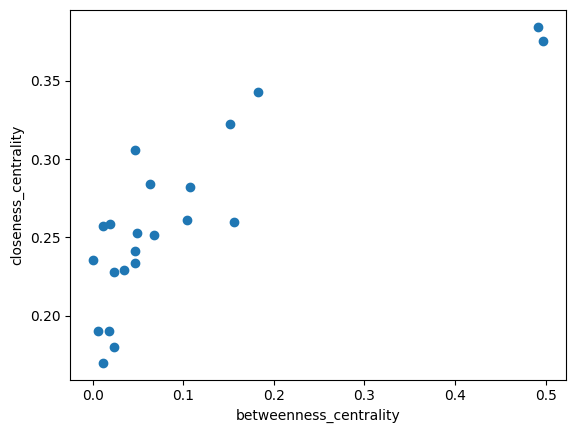

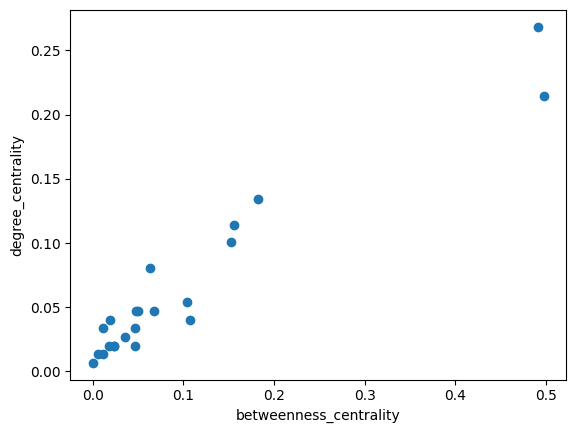

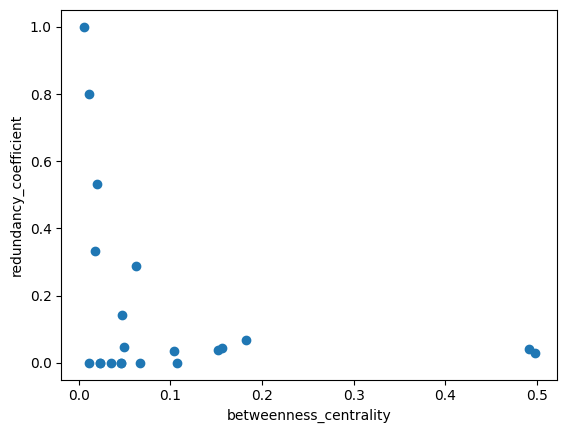

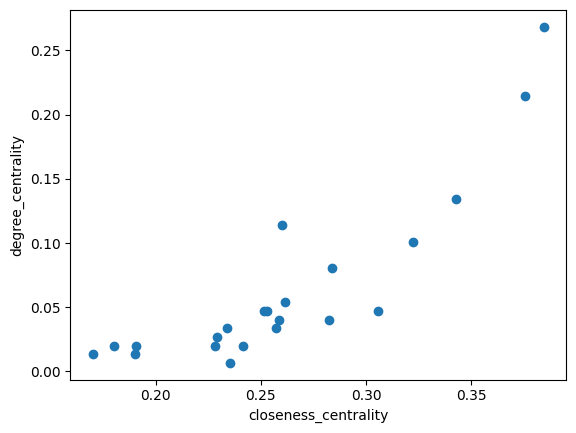

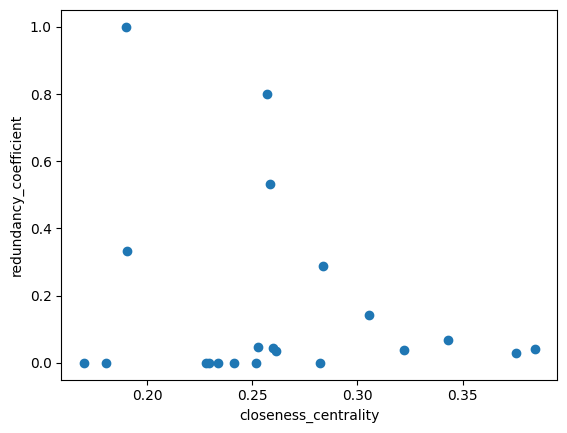

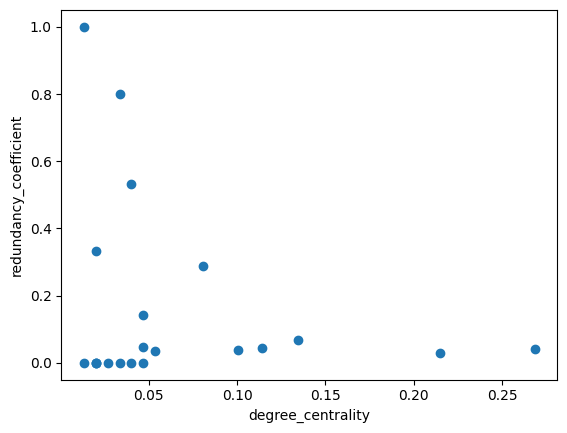

In [20]:
partition_report('MicroRNA', df_nodes)

+++++++++ Messenger RNAs +++++++++
> number of nodes: 233
> average degree: 1.27

========= largest component =========
> number of nodes: 149
> average degree: 1.4

> top-5 nodes by degree in descending order 
     label  degree
0    ATXN1       4
1  RASGRF2       4
2     ESR1       4
3    CCND2       3
4   RAB27A       3

> top-5 nodes by betweenness centrality in descending order 
    label  betweenness_centrality
0   ATXN1                0.164538
1  RAB27A                0.093546
2    BNC2                0.083622
3    ZEB1                0.072088
4   CCND2                0.071987

> top-5 nodes by closeness centrality in descending order 
      label  closeness_centrality
0     CCND2              0.593284
1  KIAA0513              0.582418
2      TNS1              0.582418
3     TACC1              0.582418
4     ATXN1              0.546392

> top-5 nodes by degree centrality in descending order 
     label  degree_centrality
0    ATXN1           0.181818
1  RASGRF2           0.18181

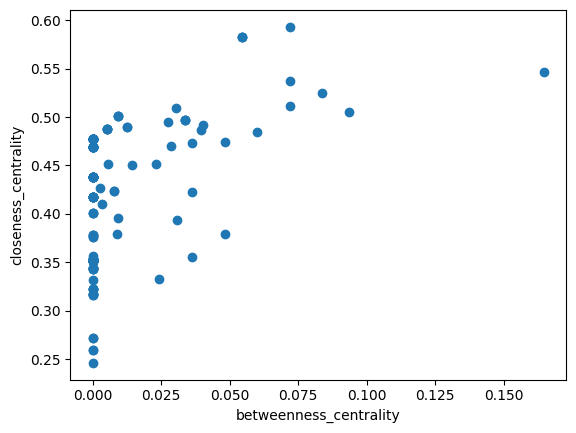

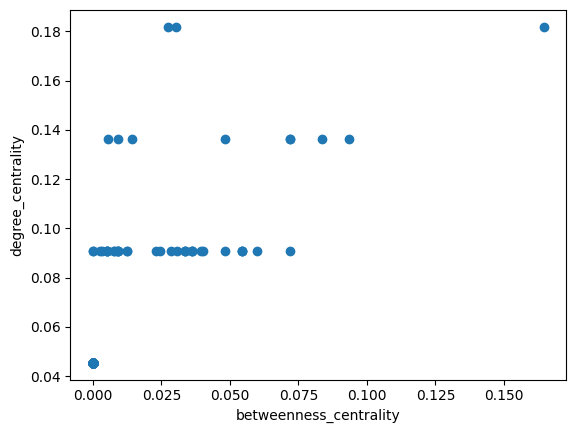

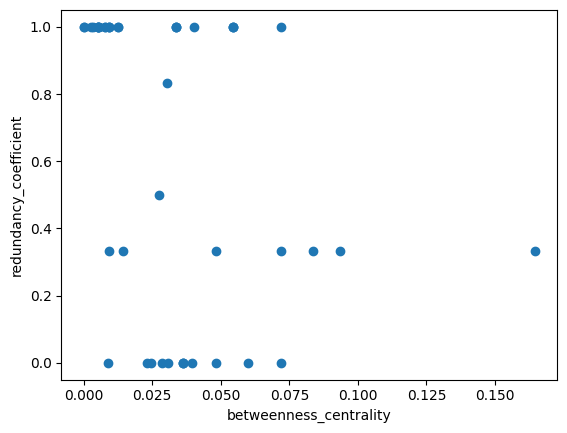

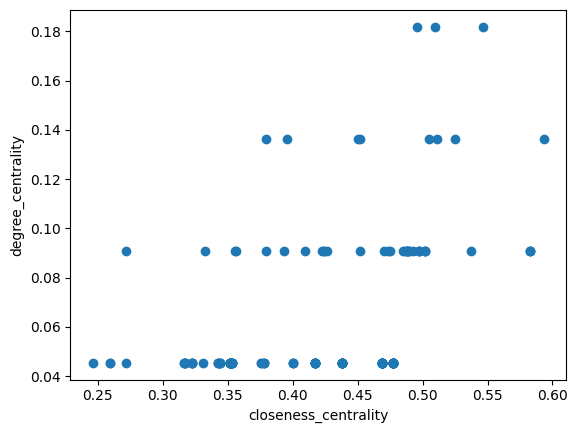

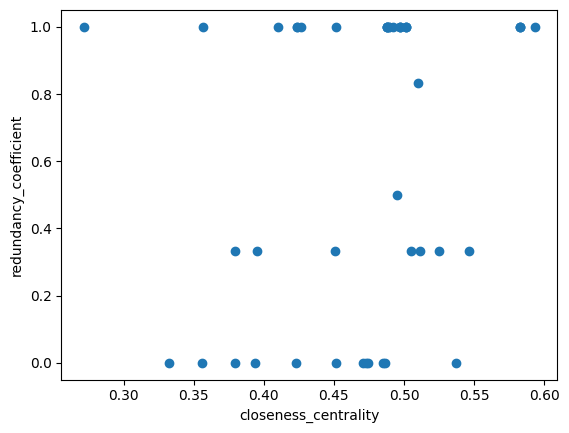

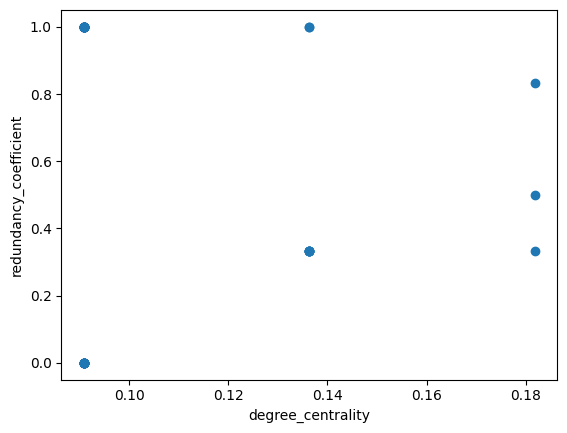

In [21]:
partition_report('Messenger RNA', df_nodes)

### Membership Network

In [22]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='membership')

In [23]:
global_report(df_edges, df_nodes)

> number of nodes: 59
> number of edges: 117
> number of connected components: 1
> number of nodes per module: 
module_id
0.0    40
1.0    14
2.0     2
3.0     2
4.0     1
Name: count, dtype: int64


+++++++++ Messenger RNAs +++++++++
> number of nodes: 46
> average degree: 2.54
> top-5 nodes by degree in descending order 
     label  degree
0  CD200R1      11
1   CCDC50      10
2    CHST1       7
3     AFF1       6
4  B4GALT5       5

> top-5 nodes by betweenness centrality in descending order 
     label  betweenness_centrality
0  CD200R1                0.213343
1   CCDC50                0.152677
2    CHST1                0.074925
3  B4GALT5                0.060863
4     AFF1                0.050956

> top-5 nodes by closeness centrality in descending order 
     label  closeness_centrality
0  CD200R1              0.880342
1   CCDC50              0.851240
2    CHST1              0.730496
3  B4GALT5              0.720280
4    CCND2              0.691275

> top-5 nodes by degree centrality in descending order 
     label  degree_centrality
0  CD200R1           0.846154
1   CCDC50           0.769231
2    CHST1           0.538462
3     AFF1           0.461538
4  B4GALT5           0.3

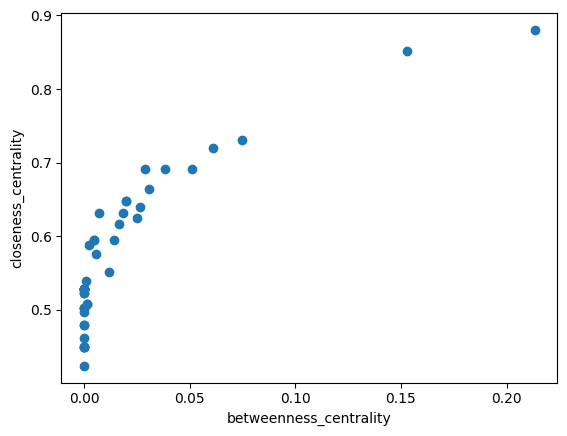

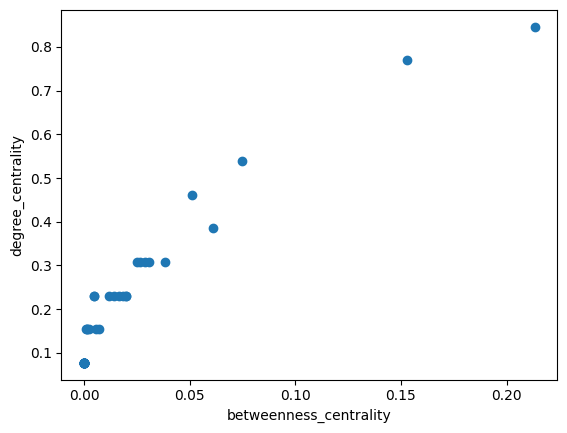

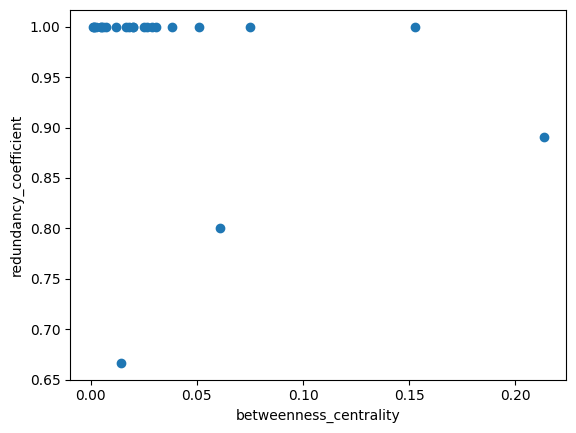

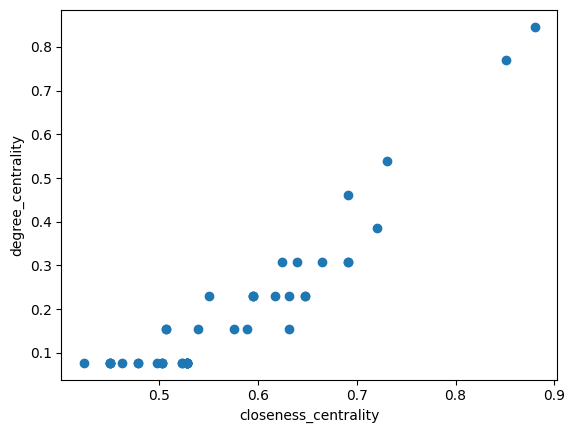

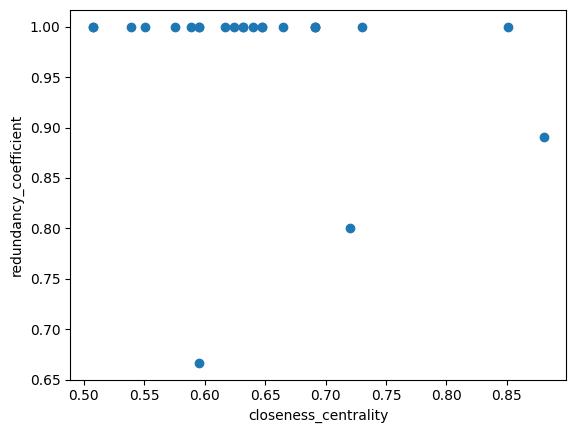

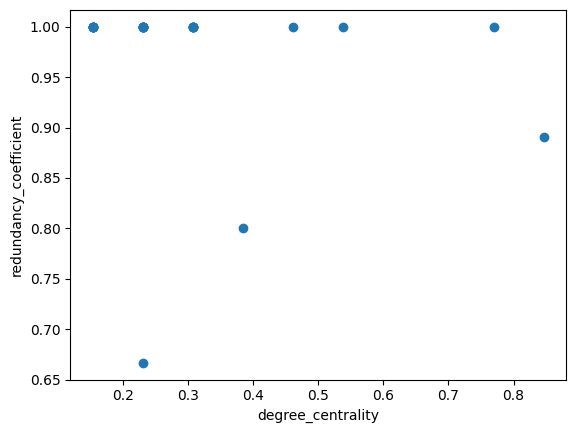

In [24]:
partition_report('Messenger RNA', df_nodes)

+++++++++ Pathways +++++++++
> number of nodes: 13
> average degree: 9.0
> top-5 nodes by degree in descending order 
                                     label  degree
0                       Pathways in cancer      18
1  Transcriptional misregulation in cancer      17
2                Calcium signaling pathway      11
3                   MAPK signaling pathway      11
4                  Proteoglycans in cancer       9

> top-5 nodes by betweenness centrality in descending order 
                                     label  betweenness_centrality
0  Transcriptional misregulation in cancer                0.303593
1                       Pathways in cancer                0.266365
2                Calcium signaling pathway                0.154318
3                   MAPK signaling pathway                0.131449
4                  Proteoglycans in cancer                0.097448

> top-5 nodes by closeness centrality in descending order 
                                     label  closenes

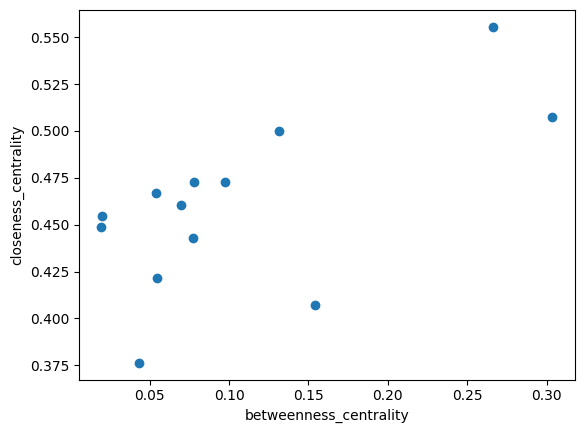

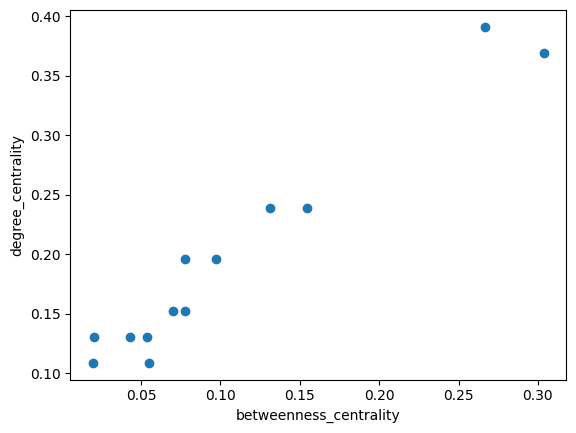

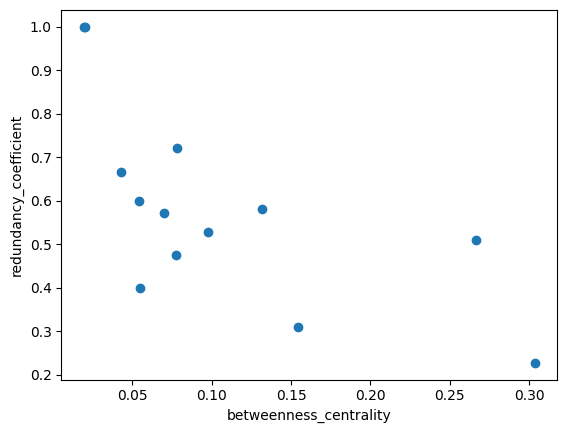

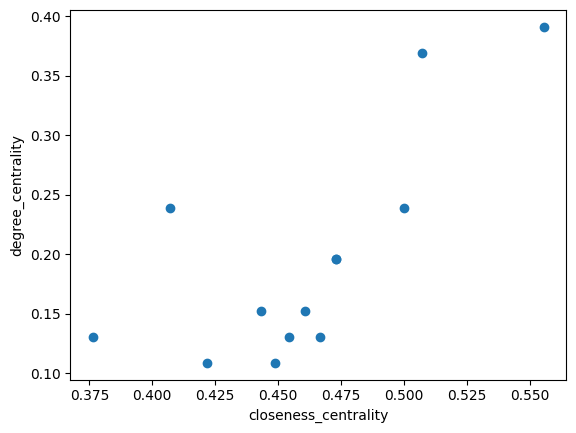

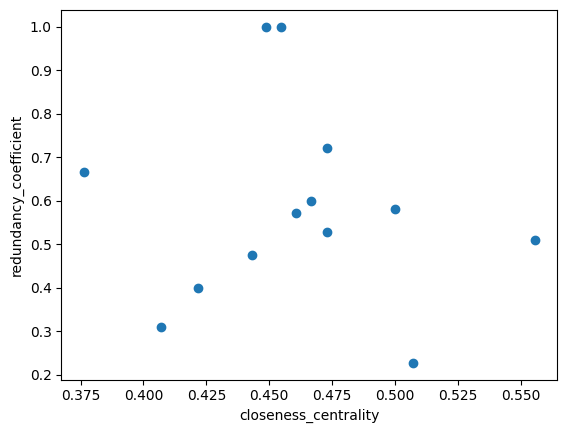

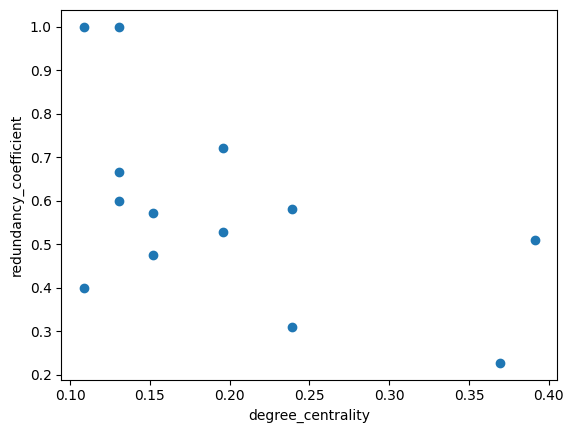

In [25]:
partition_report('Pathway', df_nodes)

## Luminal A

In [26]:
group = 'Luminal A'

In [27]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='interaction')

In [28]:
global_report(df_edges, df_nodes)

> number of nodes: 251
> number of edges: 259
> number of connected components: 22
> number of nodes per module: 
module_id
0.0    198
1.0     47
2.0      2
3.0      2
4.0      2
Name: count, dtype: int64


+++++++++ MicroRNAs +++++++++
> number of nodes: 44
> average degree: 5.89

========= largest component =========
> number of nodes: 21
> average degree: 10.81

> top-5 nodes by degree in descending order 
             label  degree
0    hsa-miR-96-5p      38
1   hsa-miR-29b-3p      27
2   hsa-miR-141-3p      16
3  hsa-miR-200a-3p      14
4  hsa-miR-200b-3p      14

> top-5 nodes by betweenness centrality in descending order 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.564774
1   hsa-miR-29b-3p                0.242159
2  hsa-miR-200b-3p                0.234775
3   hsa-miR-141-3p                0.232485
4  hsa-miR-301a-3p                0.222737

> top-5 nodes by closeness centrality in descending order 
             label  closeness_centrality
0    hsa-miR-96-5p              0.309558
1  hsa-miR-200b-3p              0.268897
2   hsa-miR-29b-3p              0.253209
3      hsa-miR-429              0.251448
4  hsa-miR-200a-3p              0.245753

> top

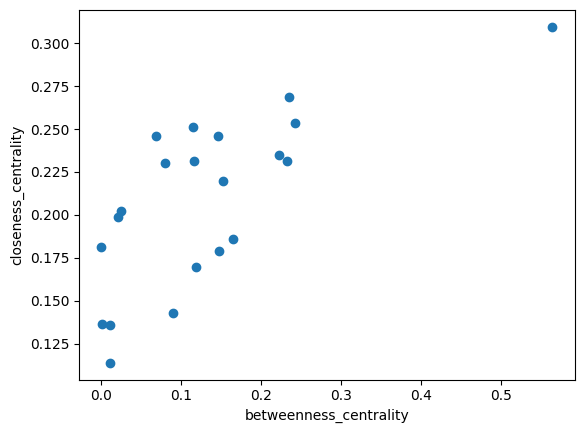

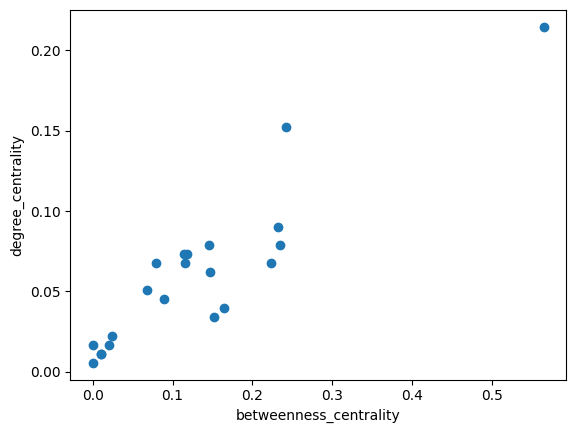

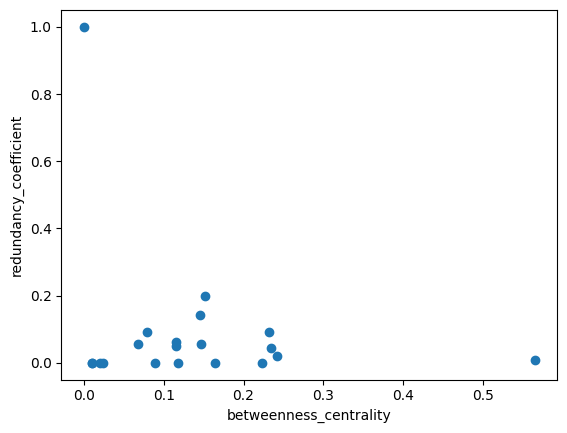

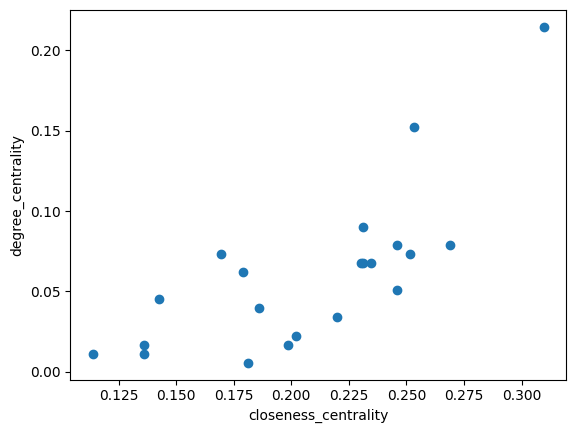

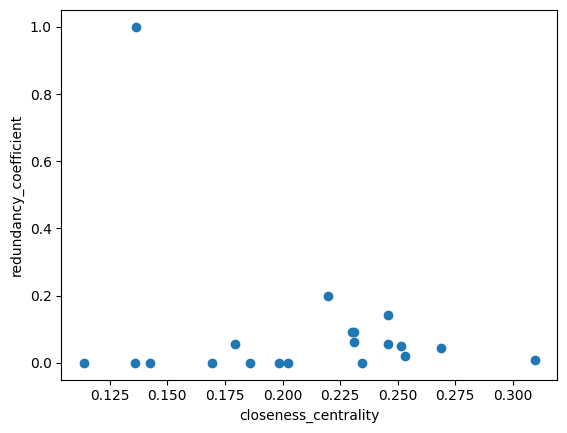

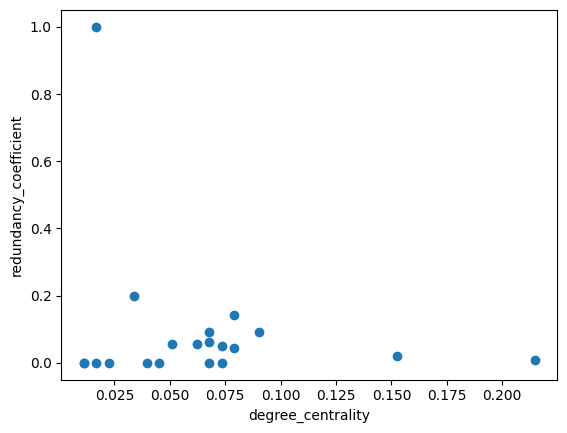

In [29]:
partition_report('MicroRNA', df_nodes)

+++++++++ Messenger RNAs +++++++++
> number of nodes: 207
> average degree: 1.25

========= largest component =========
> number of nodes: 177
> average degree: 1.28

> top-5 nodes by degree in descending order 
        label  degree
0     RUNX1T1       4
1     FAM126A       3
2  PALM2AKAP2       3
3       BACH2       3
4       CELF2       3

> top-5 nodes by betweenness centrality in descending order 
     label  betweenness_centrality
0     EBF3                0.218683
1   PXYLP1                0.139343
2  RUNX1T1                0.133915
3     CROT                0.131355
4    BACH2                0.131239

> top-5 nodes by closeness centrality in descending order 
   label  closeness_centrality
0  CELF2              0.487582
1  BACH2              0.480051
2   ZEB1              0.477593
3  PCSK5              0.465668
4   EBF3              0.458795

> top-5 nodes by degree centrality in descending order 
        label  degree_centrality
0     RUNX1T1           0.190476
1     FAM126A  

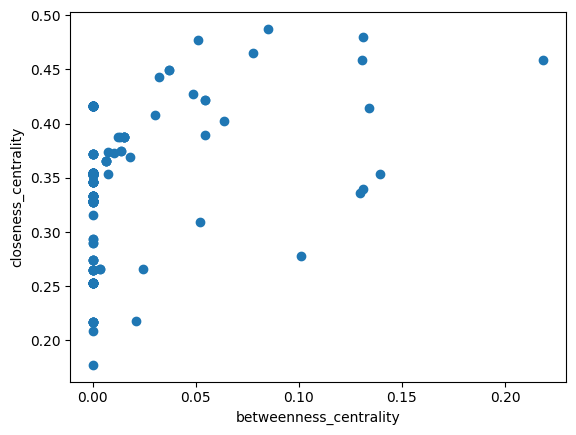

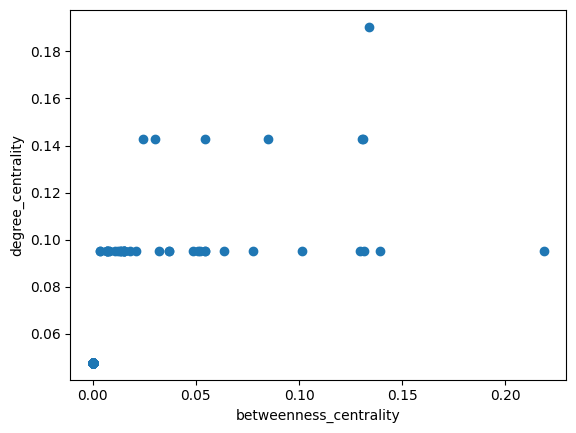

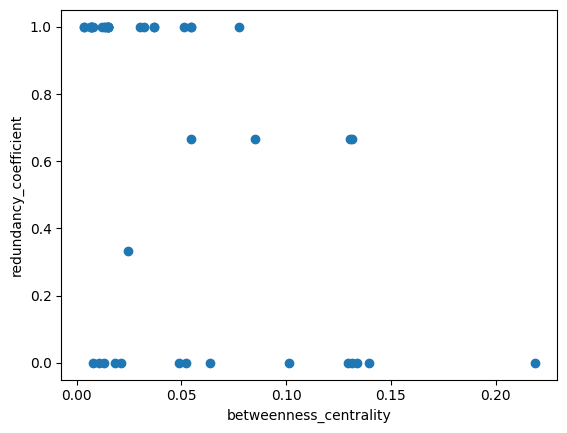

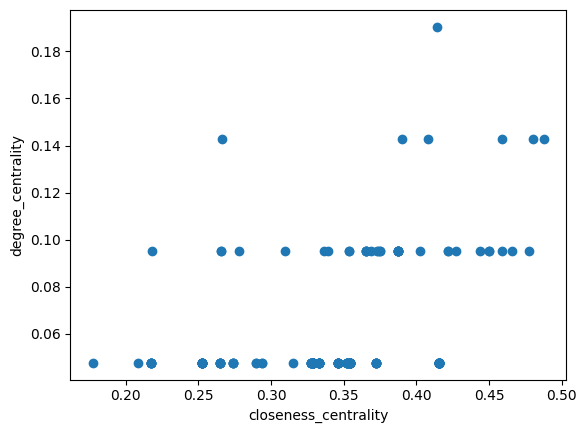

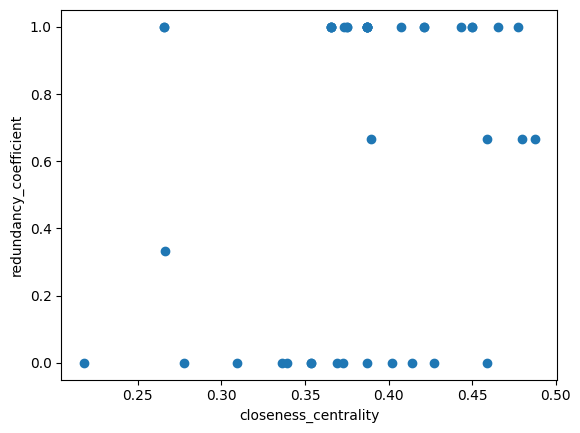

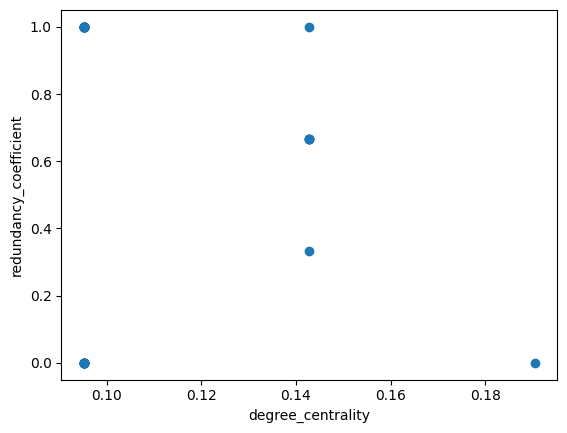

In [30]:
partition_report('Messenger RNA', df_nodes)

In [31]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='membership')

In [32]:
global_report(df_edges, df_nodes)

> number of nodes: 34
> number of edges: 50
> number of connected components: 1
> number of nodes per module: 
module_id
0.0    19
1.0     9
2.0     2
3.0     2
4.0     2
Name: count, dtype: int64


+++++++++ Messenger RNAs +++++++++
> number of nodes: 29
> average degree: 1.72
> top-5 nodes by degree in descending order 
   label  degree
0   TCF4       5
1  PRKG1       3
2    MAF       3
3  TRPM3       3
4  LAMA2       3

> top-5 nodes by betweenness centrality in descending order 
   label  betweenness_centrality
0   TCF4                0.442784
1  HMCN1                0.049770
2  ITGA9                0.044176
3    MAF                0.043723
4   TBX3                0.043723

> top-5 nodes by closeness centrality in descending order 
   label  closeness_centrality
0   TCF4              1.000000
1  PRKG1              0.717647
2    MAF              0.717647
3  TRPM3              0.717647
4  LAMA2              0.717647

> top-5 nodes by degree centrality in descending order 
   label  degree_centrality
0   TCF4                1.0
1  PRKG1                0.6
2    MAF                0.6
3  TRPM3                0.6
4  LAMA2                0.6

> top-5 nodes by redundancy coefficient i

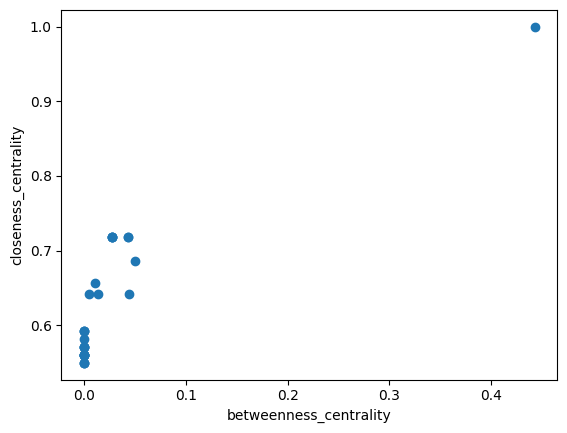

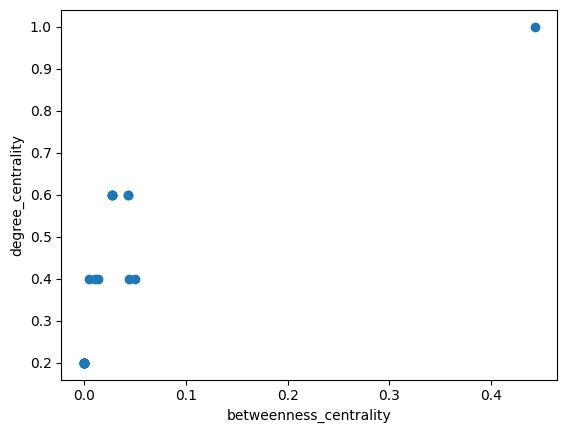

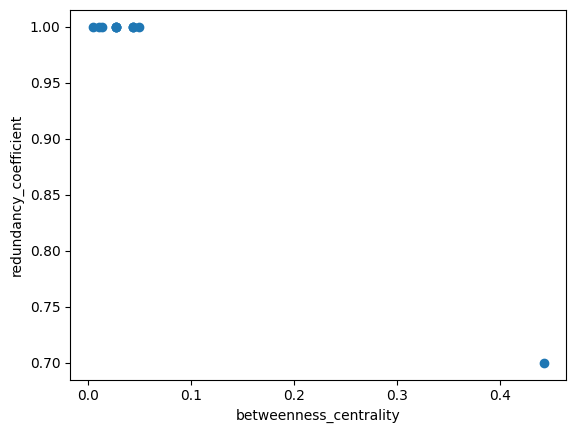

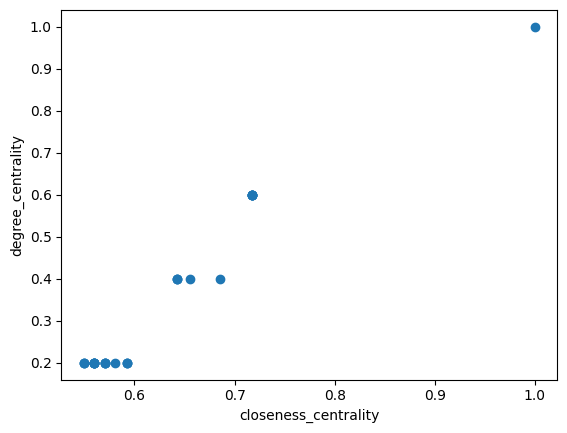

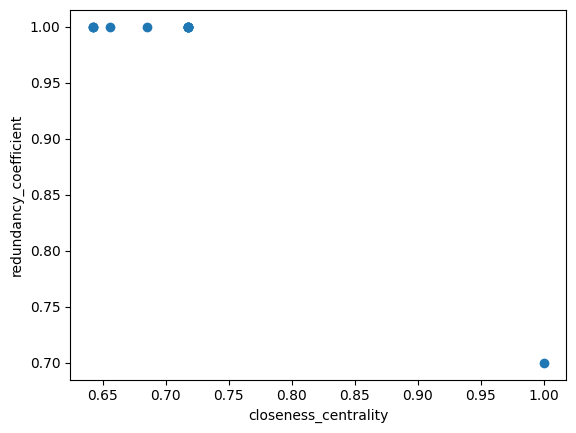

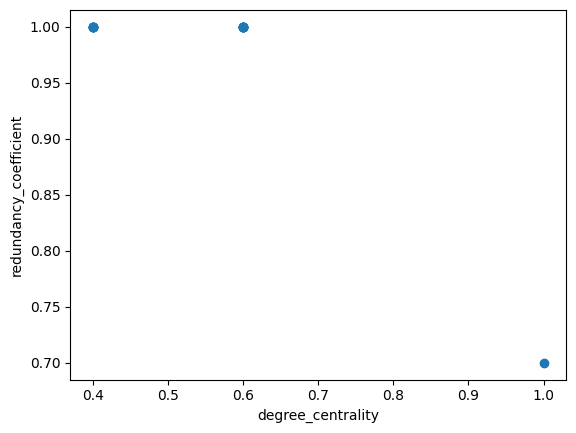

In [33]:
partition_report('Messenger RNA', df_nodes)

+++++++++ Pathways +++++++++
> number of nodes: 5
> average degree: 10.0
> top-5 nodes by degree in descending order 
                                     label  degree
0               PI3K-Akt signaling pathway      12
1           Human papillomavirus infection      11
2                           Focal adhesion      10
3  Transcriptional misregulation in cancer       9
4                  Hippo signaling pathway       8

> top-5 nodes by betweenness centrality in descending order 
                                     label  betweenness_centrality
0  Transcriptional misregulation in cancer                0.358545
1               PI3K-Akt signaling pathway                0.284897
2                           Focal adhesion                0.274533
3           Human papillomavirus infection                0.238590
4                  Hippo signaling pathway                0.232747

> top-5 nodes by closeness centrality in descending order 
                                     label  closenes

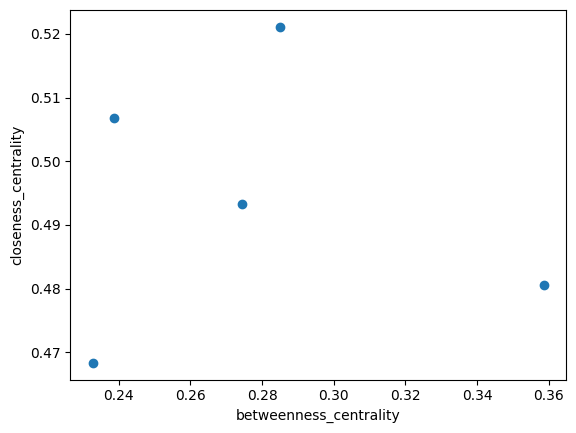

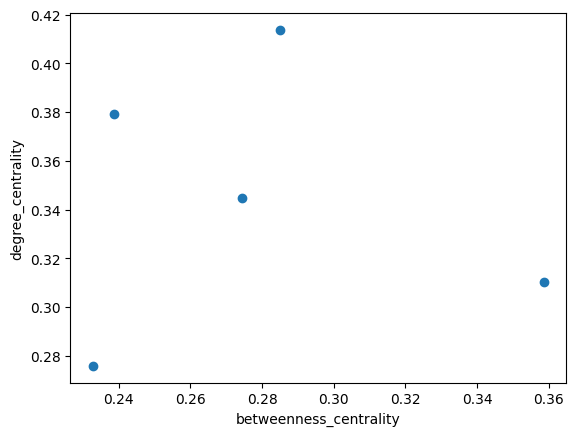

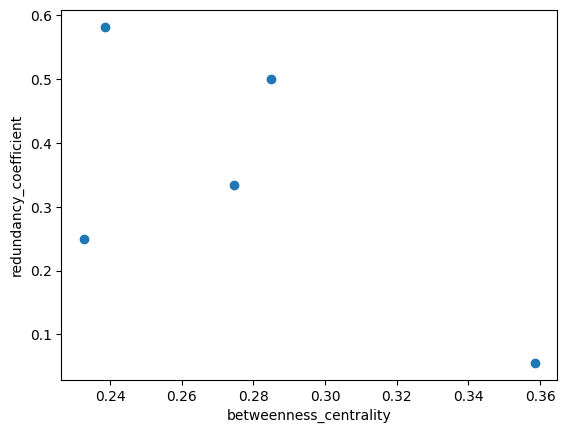

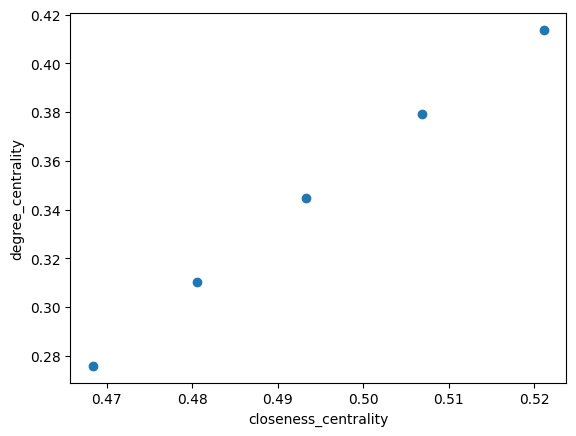

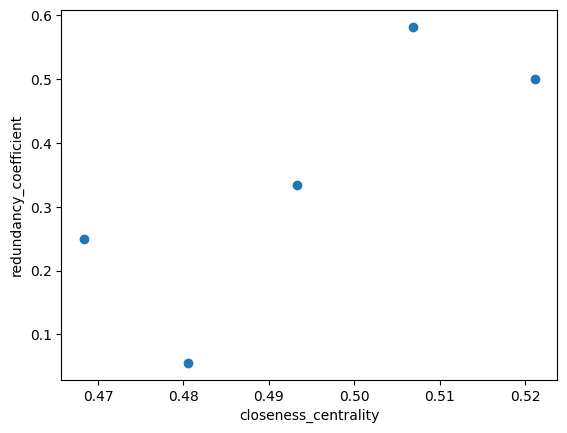

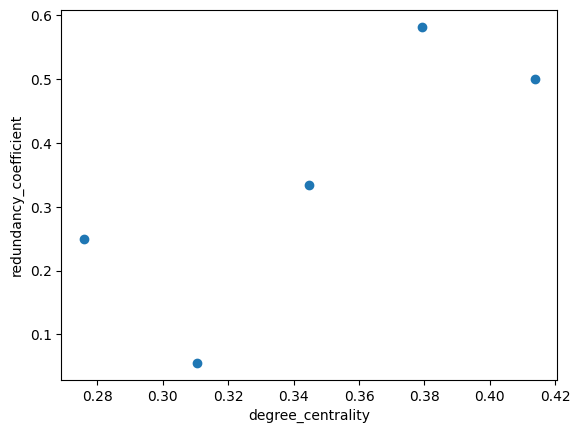

In [34]:
partition_report('Pathway', df_nodes)

## Luminal B

In [35]:
group = 'Luminal B'

In [36]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='interaction')

In [37]:
global_report(df_edges, df_nodes)

> number of nodes: 559
> number of edges: 584
> number of connected components: 38
> number of nodes per module: 
module_id
0.0    446
1.0    107
2.0      2
3.0      2
4.0      2
Name: count, dtype: int64


+++++++++ MicroRNAs +++++++++
> number of nodes: 105
> average degree: 5.56

========= largest component =========
> number of nodes: 66
> average degree: 7.97

> top-5 nodes by degree in descending order 
             label  degree
0  hsa-miR-200c-3p      32
1   hsa-miR-27b-3p      32
2   hsa-miR-33a-5p      28
3  hsa-miR-106b-5p      24
4   hsa-miR-34a-5p      20

> top-5 nodes by betweenness centrality in descending order 
             label  betweenness_centrality
0  hsa-miR-200c-3p                0.251333
1  hsa-miR-106b-5p                0.234669
2   hsa-miR-27b-3p                0.196048
3   hsa-miR-18a-5p                0.174641
4   hsa-miR-33a-5p                0.167084

> top-5 nodes by closeness centrality in descending order 
             label  closeness_centrality
0  hsa-miR-106b-5p              0.277311
1  hsa-miR-200c-3p              0.259843
2   hsa-miR-18a-5p              0.254090
3  hsa-miR-130b-3p              0.252149
4   hsa-miR-27b-3p              0.248588

> top

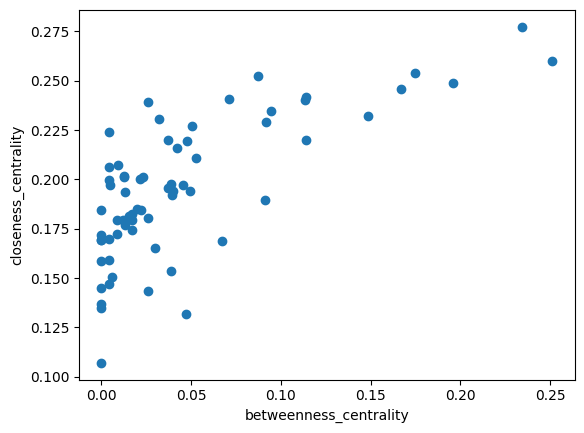

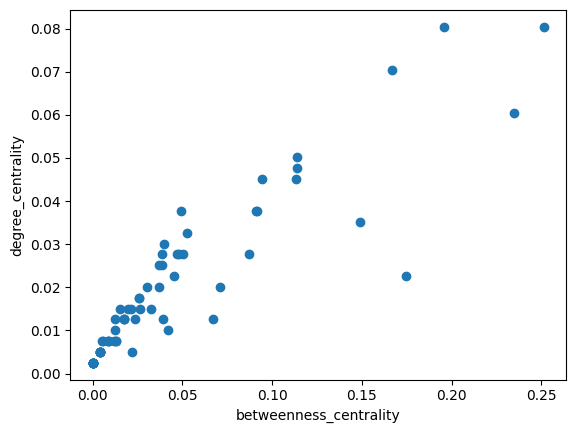

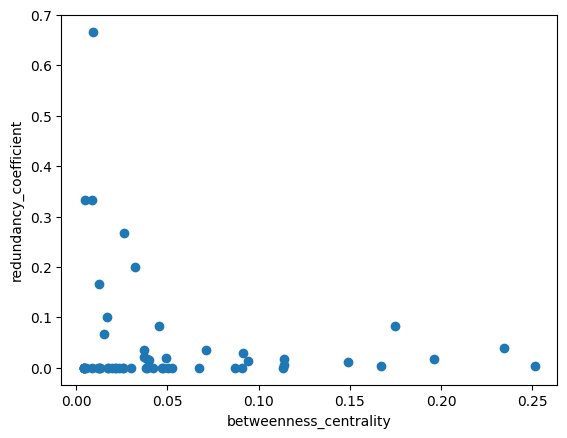

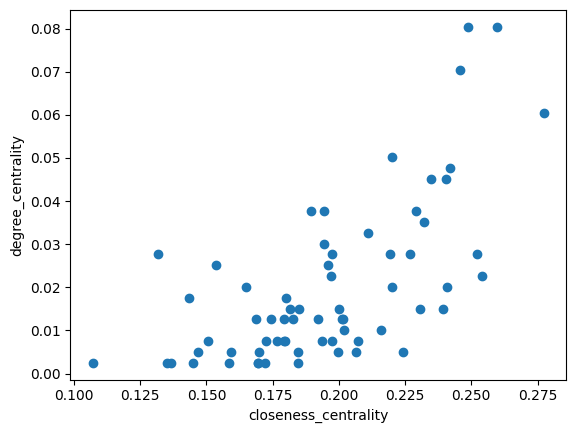

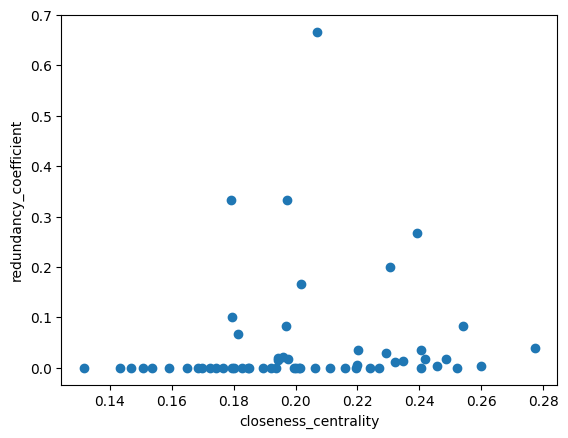

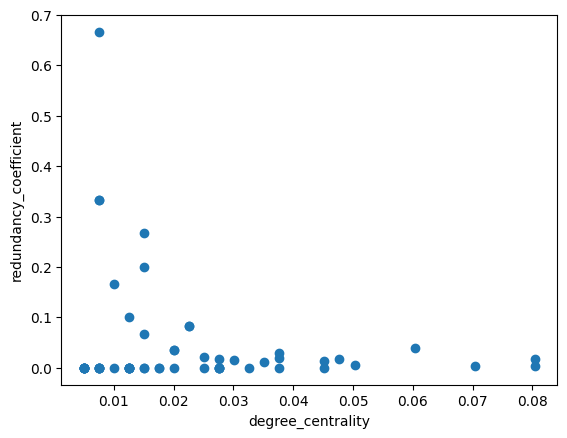

In [38]:
partition_report('MicroRNA', df_nodes)

+++++++++ Messenger RNAs +++++++++
> number of nodes: 454
> average degree: 1.29

========= largest component =========
> number of nodes: 398
> average degree: 1.32

> top-5 nodes by degree in descending order 
      label  degree
0    ZBTB20       7
1     ATXN1       5
2  SH3PXD2A       5
3     CPEB4       5
4    MAP4K4       5

> top-5 nodes by betweenness centrality in descending order 
    label  betweenness_centrality
0  ZBTB20                0.166059
1  MAP4K4                0.127483
2   PEAK1                0.089503
3   KLF12                0.085418
4    EOGT                0.071826

> top-5 nodes by closeness centrality in descending order 
    label  closeness_centrality
0  ZBTB20              0.453586
1   ATXN1              0.409914
2   PEAK1              0.404516
3  MAP4K4              0.393413
4  FNDC3A              0.391621

> top-5 nodes by degree centrality in descending order 
      label  degree_centrality
0    ZBTB20           0.106061
1     ATXN1           0.075758


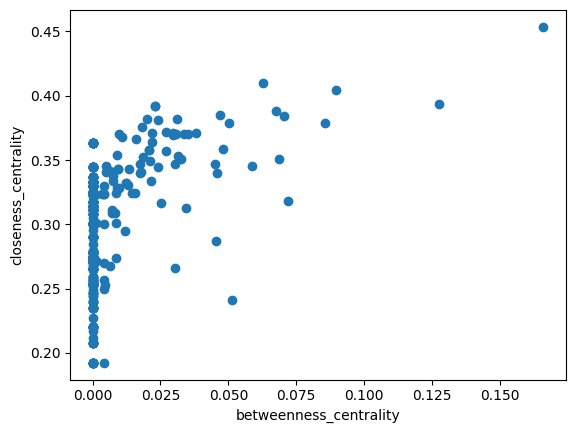

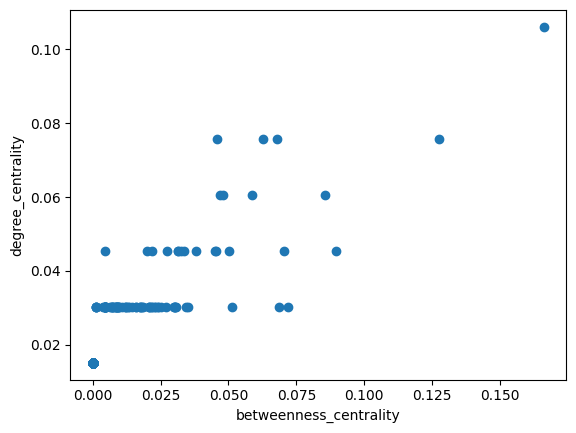

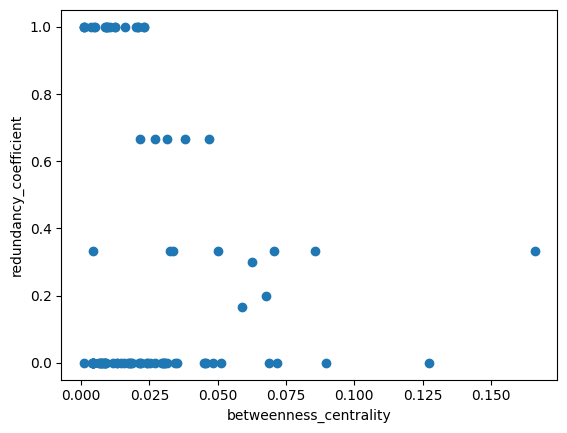

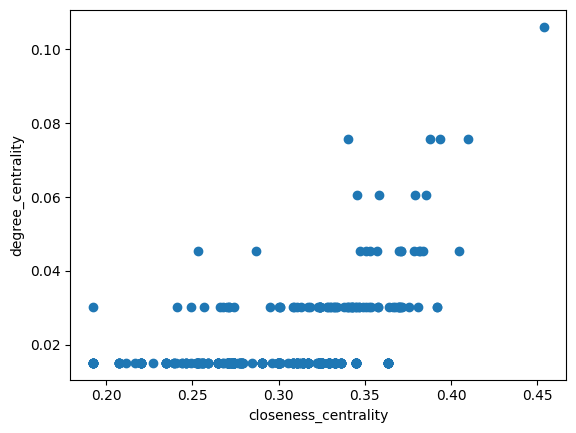

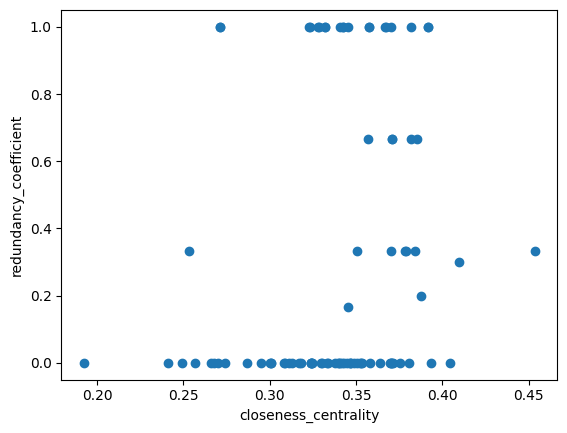

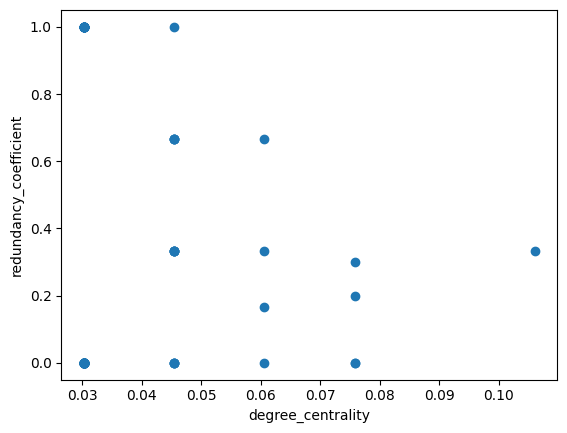

In [39]:
partition_report('Messenger RNA', df_nodes)

In [40]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='membership')

In [41]:
global_report(df_edges, df_nodes)

> number of nodes: 140
> number of edges: 393
> number of connected components: 1
> number of nodes per module: 
module_id
0.0    109
1.0     22
2.0      2
3.0      2
4.0      2
5.0      2
6.0      1
Name: count, dtype: int64


+++++++++ Messenger RNAs +++++++++
> number of nodes: 107
> average degree: 3.67
> top-5 nodes by degree in descending order 
     label  degree
0     NFIX      27
1     NAV1      21
2  RUNX1T1      19
3      ERG      17
4    DZIP1      14

> top-5 nodes by betweenness centrality in descending order 
     label  betweenness_centrality
0     NAV1                0.173773
1     NFIX                0.160989
2      ERG                0.078393
3    CALN1                0.053782
4  RUNX1T1                0.048022

> top-5 nodes by closeness centrality in descending order 
     label  closeness_centrality
0     NAV1              0.824916
1     NFIX              0.824916
2  RUNX1T1              0.710145
3      ERG              0.706052
4    CALN1              0.690141

> top-5 nodes by degree centrality in descending order 
     label  degree_centrality
0     NFIX           0.818182
1     NAV1           0.636364
2  RUNX1T1           0.575758
3      ERG           0.515152
4    DZIP1           0.

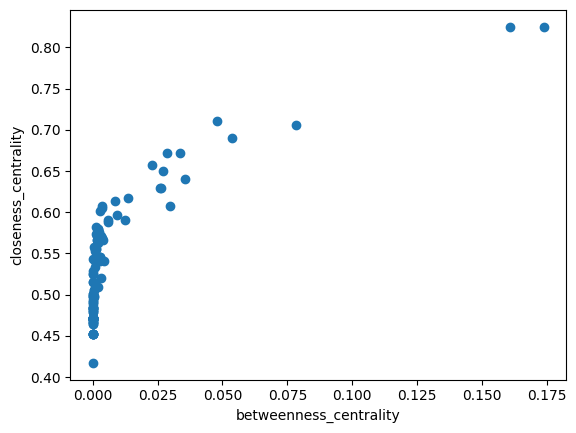

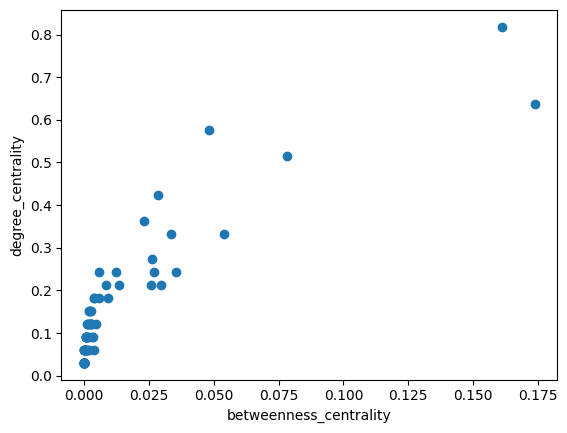

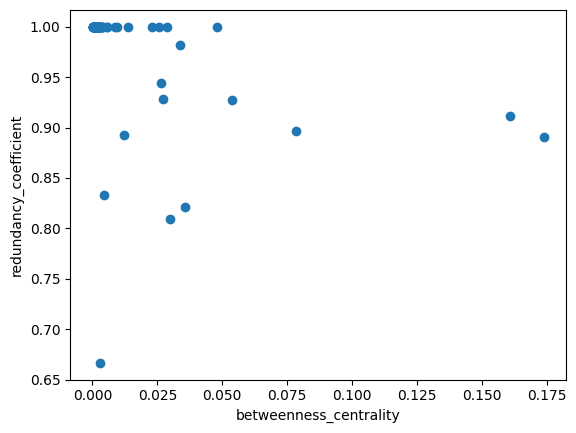

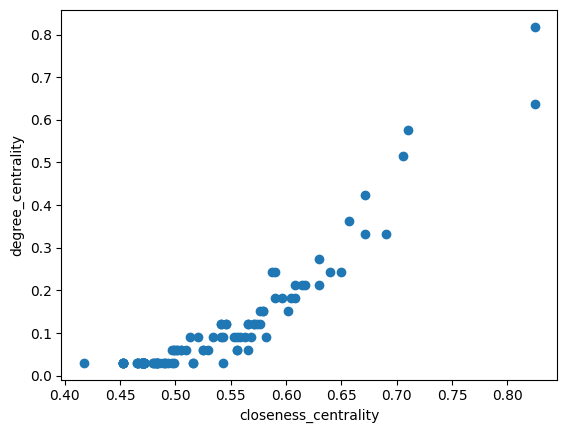

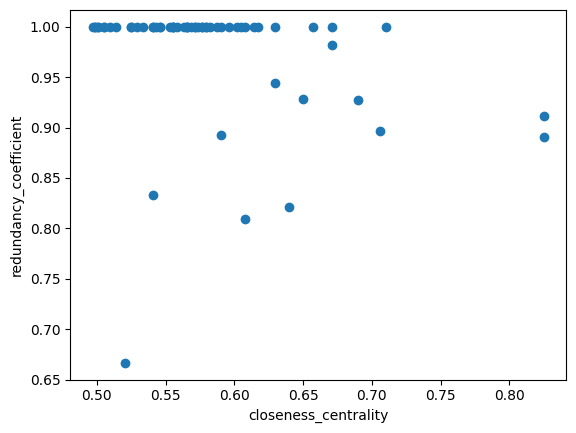

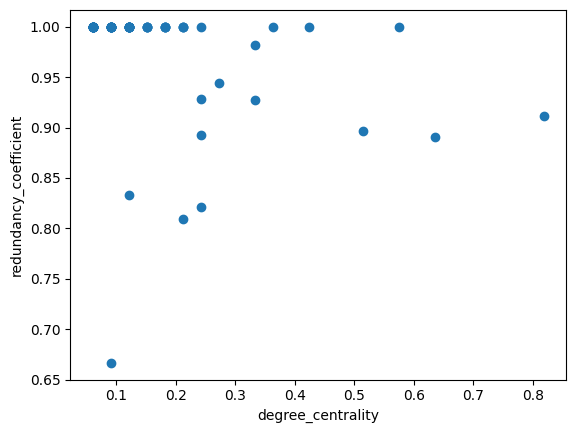

In [42]:
partition_report('Messenger RNA', df_nodes)

+++++++++ Pathways +++++++++
> number of nodes: 33
> average degree: 11.91
> top-5 nodes by degree in descending order 
                        label  degree
0          Pathways in cancer      36
1  PI3K-Akt signaling pathway      25
2      MAPK signaling pathway      24
3              Focal adhesion      16
4     Proteoglycans in cancer      15

> top-5 nodes by betweenness centrality in descending order 
                                               label  betweenness_centrality
0                                 Pathways in cancer                0.179010
1                                        Endocytosis                0.120089
2                             MAPK signaling pathway                0.104585
3  Signaling pathways regulating pluripotency of ...                0.093956
4                              Wnt signaling pathway                0.090729

> top-5 nodes by closeness centrality in descending order 
                        label  closeness_centrality
0          Pathw

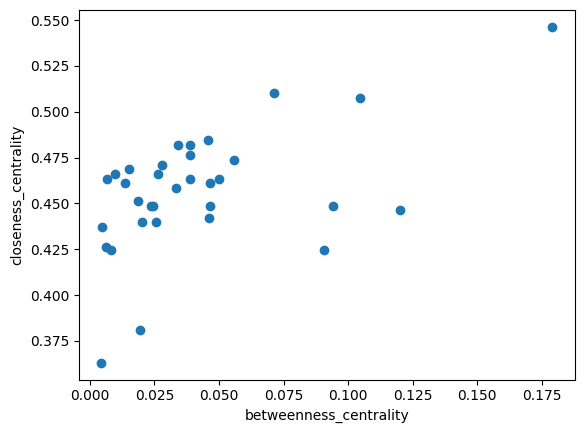

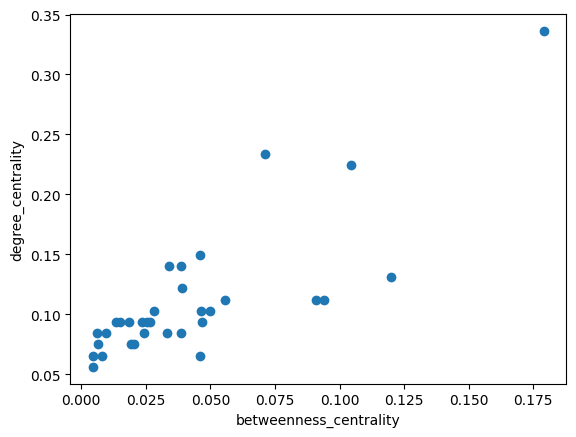

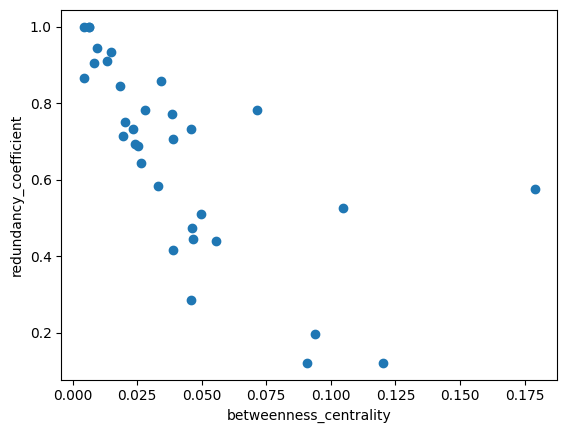

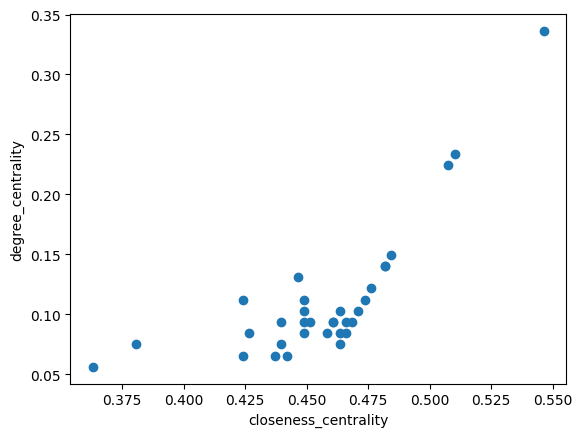

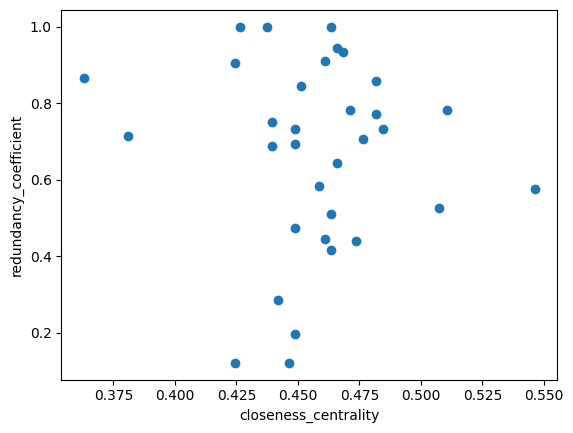

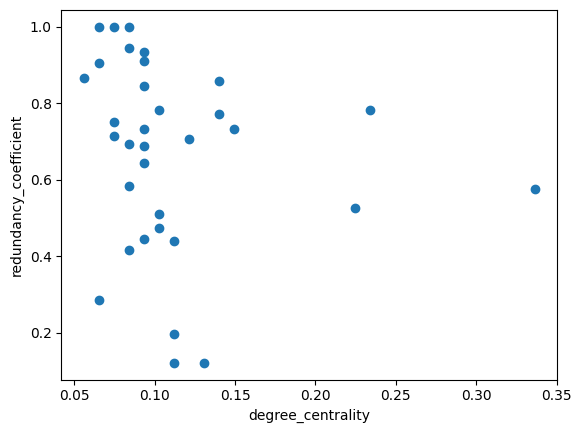

In [43]:
partition_report('Pathway', df_nodes)

## Normal

In [44]:
group = 'Normal'

In [45]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='interaction')

In [46]:
global_report(df_edges, df_nodes)

> number of nodes: 2915
> number of edges: 5072
> number of connected components: 14
> number of nodes per module: 
module_id
0.0     2720
1.0      163
2.0        2
3.0        2
4.0        2
5.0        2
6.0        2
7.0        2
8.0        2
9.0        2
10.0       2
11.0       2
12.0       2
13.0       2
14.0       2
15.0       2
16.0       2
17.0       2
Name: count, dtype: int64


+++++++++ MicroRNAs +++++++++
> number of nodes: 166
> average degree: 30.55

========= largest component =========
> number of nodes: 152
> average degree: 33.18

> top-5 nodes by degree in descending order 
             label  degree
0   hsa-miR-20b-5p     393
1   hsa-miR-15a-5p     237
2  hsa-miR-106a-5p     231
3    hsa-miR-93-5p     210
4    hsa-miR-16-5p     190

> top-5 nodes by betweenness centrality in descending order 
            label  betweenness_centrality
0   hsa-let-7d-5p                0.222570
1  hsa-miR-20b-5p                0.182494
2  hsa-miR-30e-5p                0.172102
3  hsa-miR-15a-5p                0.113808
4   hsa-miR-24-3p                0.096287

> top-5 nodes by closeness centrality in descending order 
            label  closeness_centrality
0  hsa-miR-20b-5p              0.303484
1  hsa-miR-15a-5p              0.298332
2     hsa-miR-107              0.296518
3   hsa-let-7d-5p              0.296402
4   hsa-miR-16-5p              0.295013

> top-5 nodes 

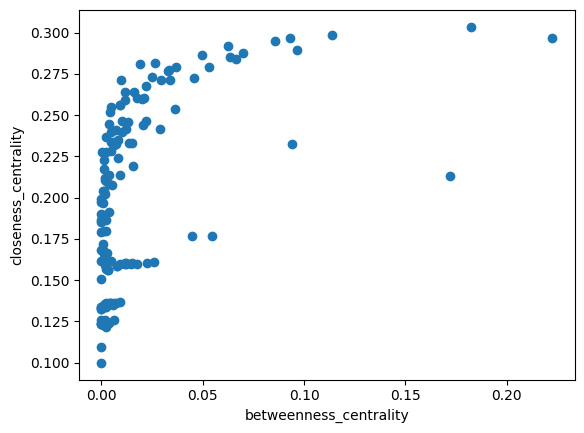

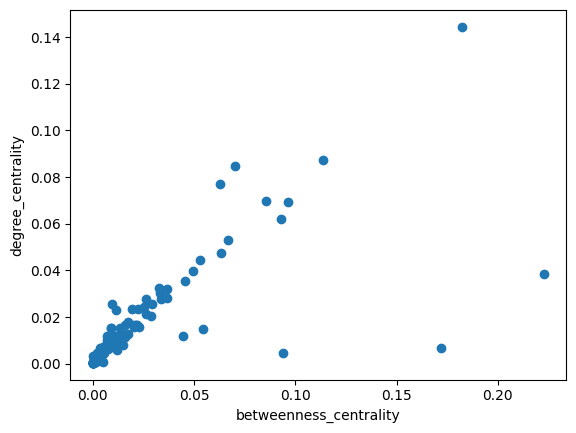

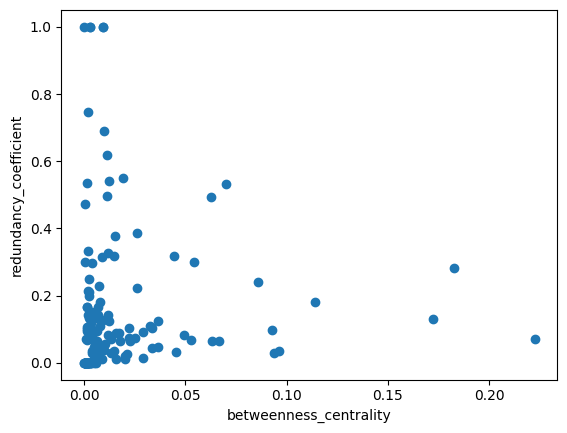

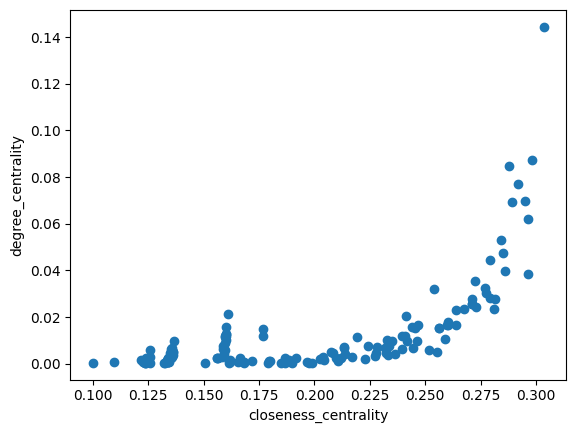

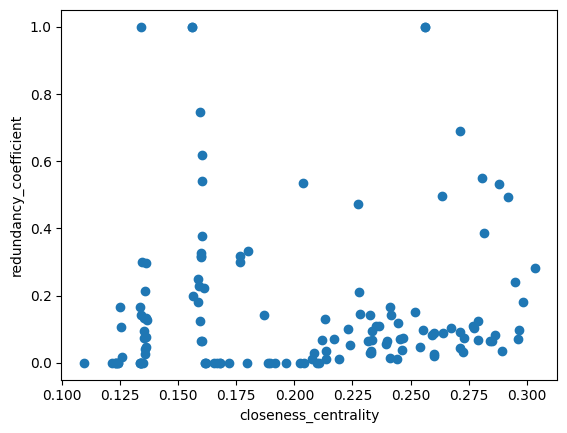

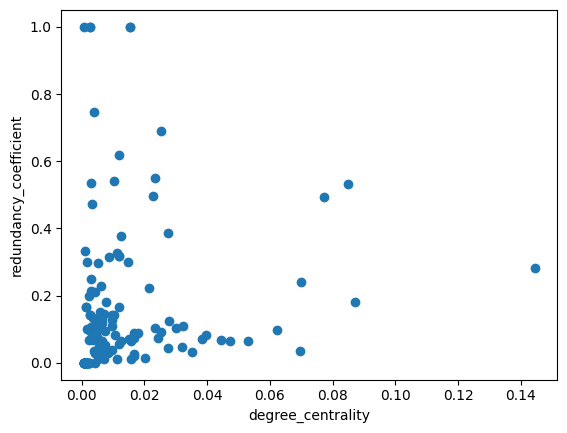

In [47]:
partition_report('MicroRNA', df_nodes)

+++++++++ Messenger RNAs +++++++++
> number of nodes: 2749
> average degree: 1.85

========= largest component =========
> number of nodes: 2721
> average degree: 1.85

> top-5 nodes by degree in descending order 
    label  degree
0    AGO1      12
1    LCOR      11
2  NUFIP2      11
3    ESR1      10
4   ITSN1      10

> top-5 nodes by betweenness centrality in descending order 
     label  betweenness_centrality
0  CCDC71L                0.177904
1   KCNJ15                0.086513
2   NFATC2                0.060283
3  DCUN1D3                0.052085
4     BNC2                0.033420

> top-5 nodes by closeness centrality in descending order 
    label  closeness_centrality
0    LCOR              0.540603
1    AGO1              0.531155
2  SRGAP1              0.506705
3  TNRC6B              0.505423
4    AAK1              0.501075

> top-5 nodes by degree centrality in descending order 
    label  degree_centrality
0    AGO1           0.078947
1    LCOR           0.072368
2  NUFIP2 

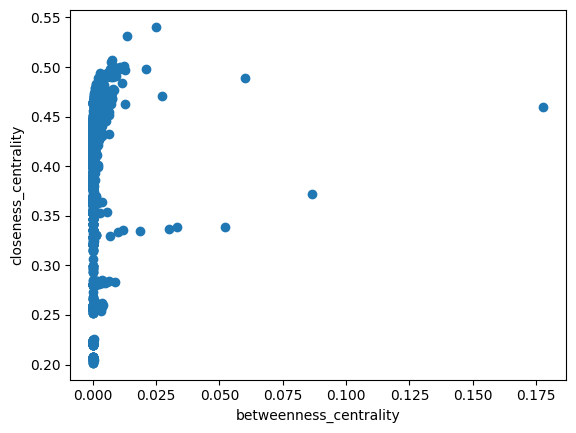

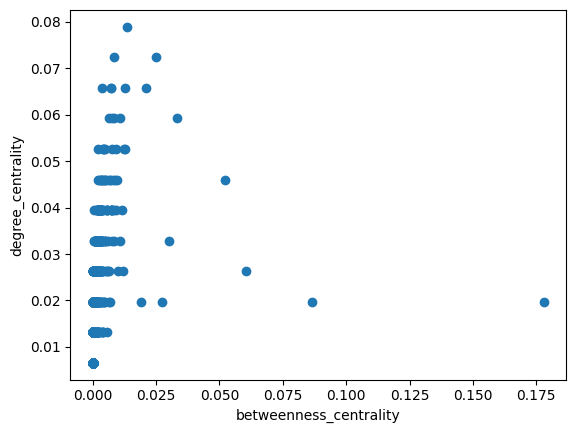

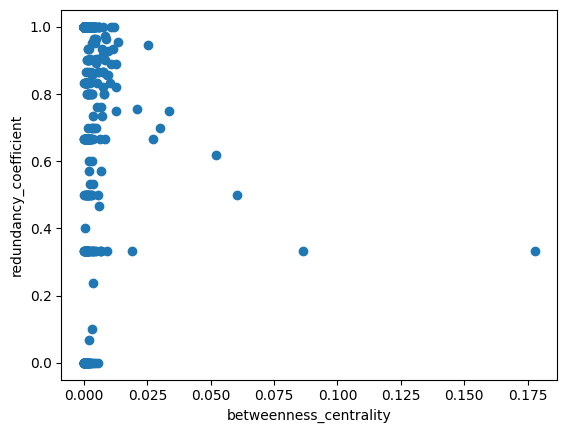

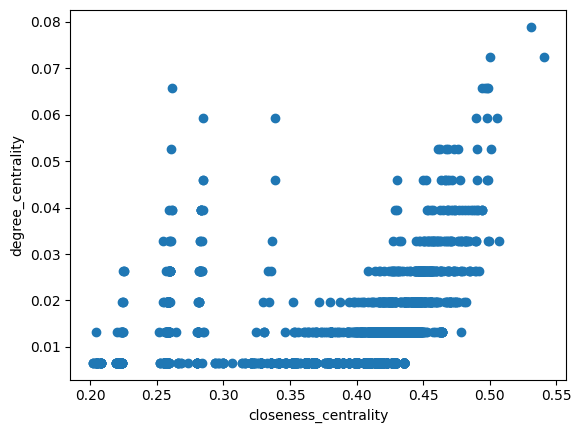

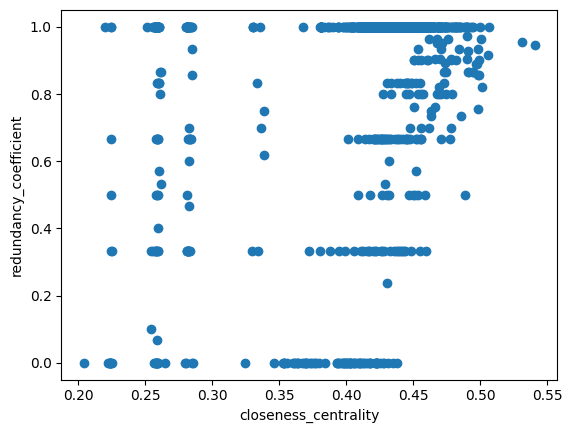

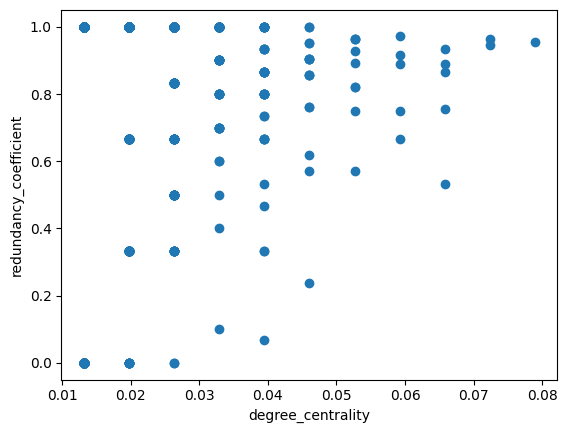

In [48]:
partition_report('Messenger RNA', df_nodes)

In [49]:
df_edges, df_nodes = setup_for_reports(group=group, network_type='membership')

In [50]:
global_report(df_edges, df_nodes)

> number of nodes: 952
> number of edges: 3871
> number of connected components: 1
> number of nodes per module: 
module_id
0.0     866
1.0      56
2.0       2
3.0       2
4.0       2
5.0       2
6.0       2
7.0       2
8.0       2
9.0       2
10.0      2
11.0      2
12.0      2
13.0      2
14.0      2
15.0      2
16.0      2
Name: count, dtype: int64


+++++++++ Messenger RNAs +++++++++
> number of nodes: 835
> average degree: 4.64
> top-5 nodes by degree in descending order 
      label  degree
0   LDLRAD3      82
1     ZC3H6      76
2   TSPOAP1      76
3  KIAA0232      76
4     UEVLD      76

> top-5 nodes by betweenness centrality in descending order 
      label  betweenness_centrality
0   LDLRAD3                0.069125
1     ZC3H6                0.043758
2  KIAA0232                0.043758
3     UEVLD                0.043758
4   TSPOAP1                0.043758

> top-5 nodes by closeness centrality in descending order 
      label  closeness_centrality
0   LDLRAD3              0.740971
1     ZC3H6              0.721795
2   TSPOAP1              0.721795
3  KIAA0232              0.721795
4     UEVLD              0.721795

> top-5 nodes by degree centrality in descending order 
      label  degree_centrality
0   LDLRAD3           0.700855
1     ZC3H6           0.649573
2   TSPOAP1           0.649573
3  KIAA0232           0.649573


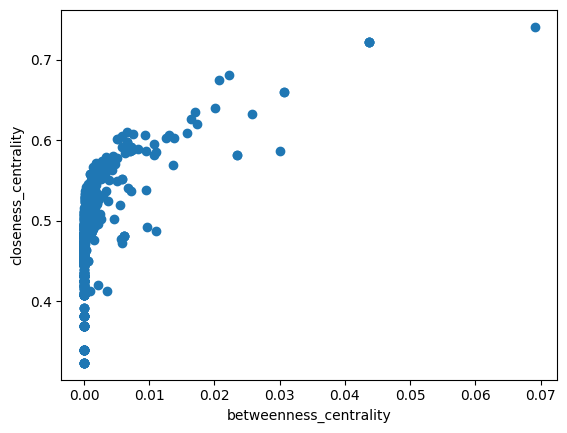

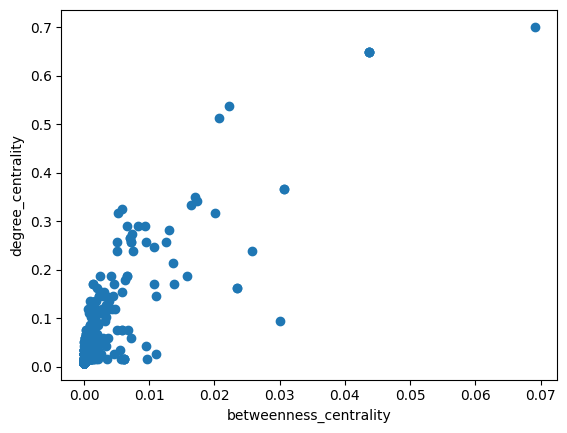

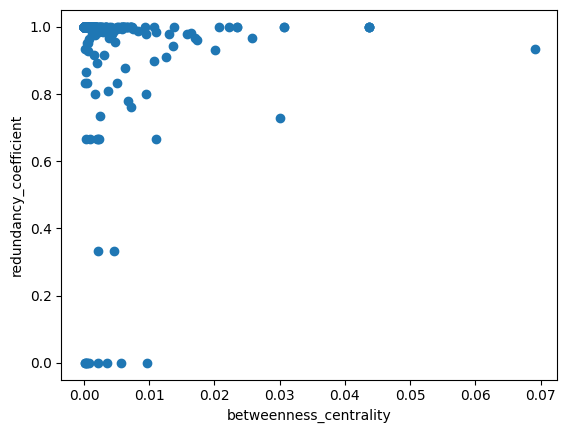

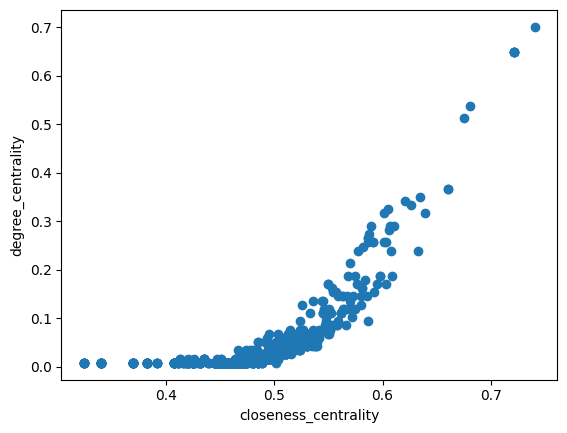

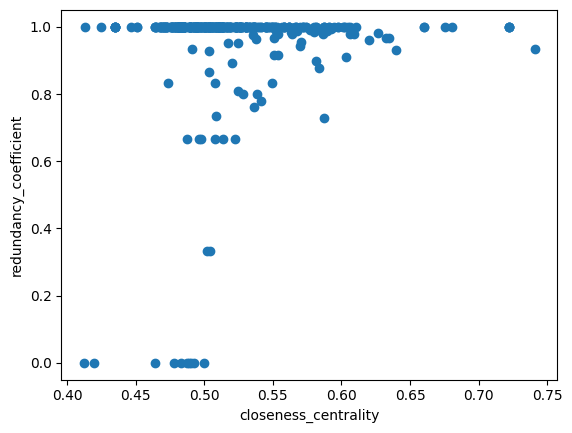

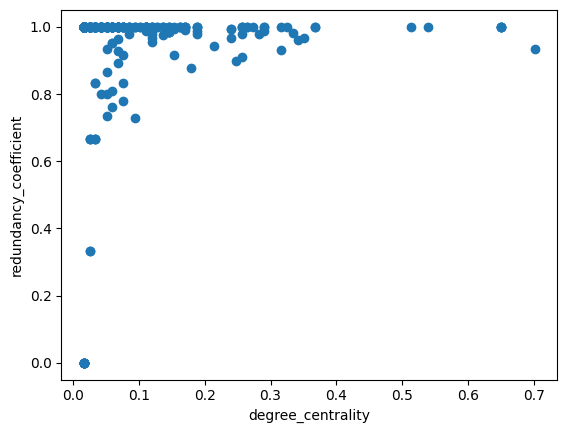

In [51]:
partition_report('Messenger RNA', df_nodes)

+++++++++ Pathways +++++++++
> number of nodes: 117
> average degree: 33.09
> top-5 nodes by degree in descending order 
                        label  degree
0          Pathways in cancer     114
1  PI3K-Akt signaling pathway      79
2      MAPK signaling pathway      75
3                 Endocytosis      62
4       Ras signaling pathway      62

> top-5 nodes by betweenness centrality in descending order 
                                         label  betweenness_centrality
0                                  Endocytosis                0.082558
1                           Pathways in cancer                0.069625
2  Protein processing in endoplasmic reticulum                0.057353
3                                Axon guidance                0.055015
4      Transcriptional misregulation in cancer                0.048666

> top-5 nodes by closeness centrality in descending order 
                                     label  closeness_centrality
0                       Pathways in ca

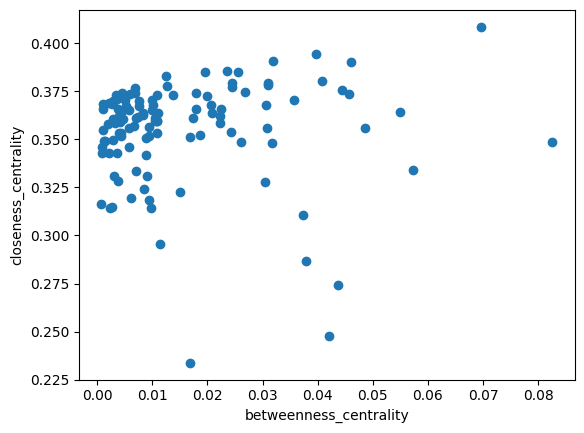

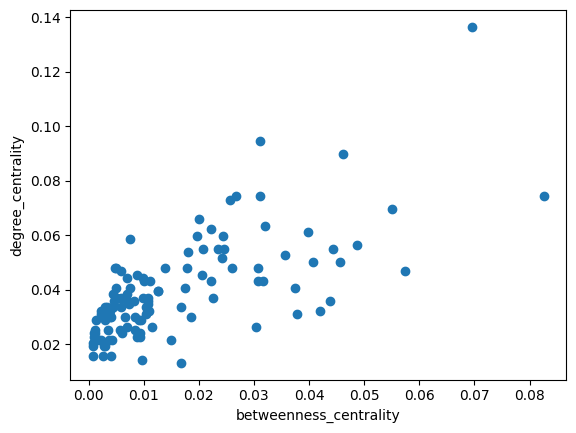

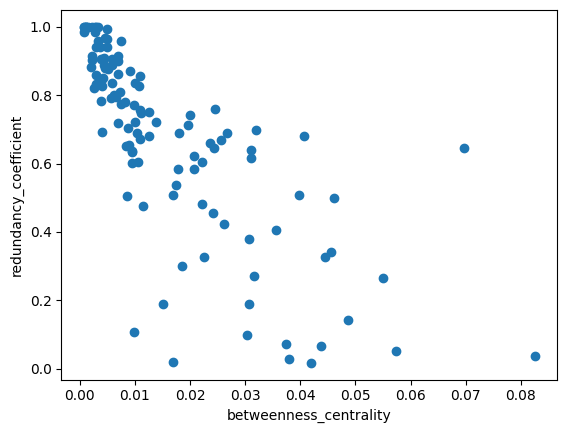

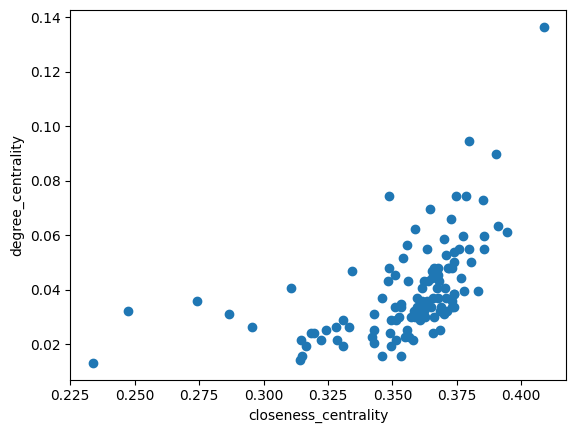

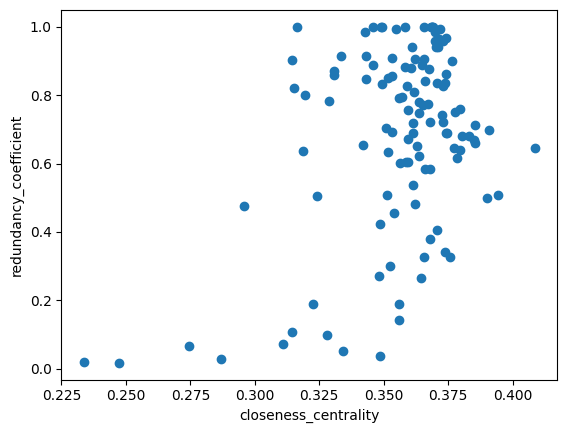

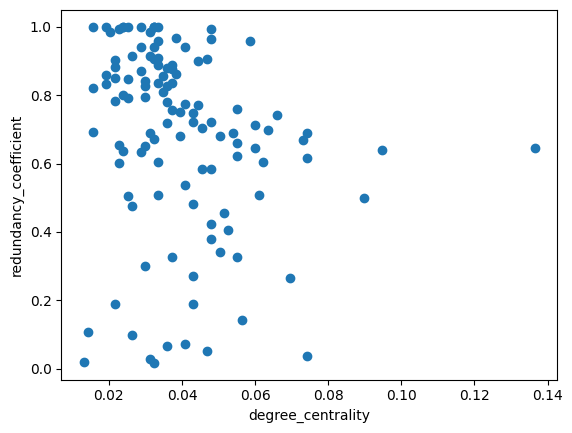

In [52]:
partition_report('Pathway', df_nodes)

# Comparative Analysis